<a href="https://colab.research.google.com/github/NickKar30/GM-HSE-AI-masters-course/blob/main/Hometasks/Base/GenDL_HT1_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание - 1 (базовая группа)

В этом домашнем задании вы потренируетесь решать задачу speech-to-text.

Вы не будете тренировать сложную архитектуру с нуля, а попробуете решить эту задачу, пройдя по пайплайну, в котором задача разбита на несколько простых шагов.

- В этом задании мы призываем вас по-максимуму использовать документацию моделей и получить опыт написания кода без заготовок

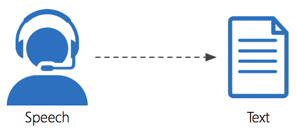

In [ ]:
!pip install evaluate jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


## Шаг 1 (1 балл)

* Возьмите датасет https://disk.yandex.ru/d/v2Hipv7XG4fEDQ, содержащий русскоязычные аудиозаписи

* Примените модель [whisper-small](https://huggingface.co/openai/whisper-small) из HF для определения сказанного в аудио.

* Выведите результат работы модели для 10 случайных аудио из датасета

Не стесняйтесь пользоваться документацией и источниками знаний из интернета!

In [ ]:
import os
import requests
from pathlib import Path

with open("urls_normalized.tsv", "r") as f:
    urls = [line.strip() for line in f if line.strip()]

# берём 10 нечётных записей
selected_indices = list(range(1, 20, 2))
selected_urls = [urls[i] for i in selected_indices]

# загрузка аудио в папку
audio_dir = Path("audio")
audio_dir.mkdir(exist_ok=True)
audio_paths = []
for i, url in enumerate(selected_urls):
    filename = audio_dir / f"audio_{i}.wav"
    if not filename.exists():
        print(f"Загрузка {i+1}/10: {url}")
        response = requests.get(url)
        with open(filename, "wb") as f:
            f.write(response.content)
    else:
        print(f"Файл {filename} уже существует")
    audio_paths.append(str(filename))

Загрузка 1/10: http://storage.mds.yandex.net:80/get-voicetoloka/1879367/3d8c8d43-f7f2-479b-a857-c90faa5e2faf
Загрузка 2/10: http://storage.mds.yandex.net:80/get-voicetoloka/1872575/3c0ebd62-2cc1-4c9c-be63-5733511a11cd
Загрузка 3/10: http://storage.mds.yandex.net:80/get-voicetoloka/2021744/c4f3178c-14b2-44f8-b36e-f34a47520e10
Загрузка 4/10: http://storage.mds.yandex.net:80/get-voicetoloka/1872575/4711cdac-8181-4f3c-8889-77cf408f3ff2
Загрузка 5/10: http://storage.mds.yandex.net:80/get-voicetoloka/2021744/d203c652-509b-4c41-bdaf-f374e1c3c87e
Загрузка 6/10: http://storage.mds.yandex.net:80/get-voicetoloka/1879367/a6bab1dc-059b-4f93-a2ec-baef363ddcea
Загрузка 7/10: http://storage.mds.yandex.net:80/get-voicetoloka/1872575/29c0f7f4-9701-4e19-a4cd-874ec5397be1
Загрузка 8/10: http://storage.mds.yandex.net:80/get-voicetoloka/2021744/969c8460-29a8-4c6a-ac71-bc729a6d1f3d
Загрузка 9/10: http://storage.mds.yandex.net:80/get-voicetoloka/1879367/2a6d78d6-5b79-4ec1-bd9b-29b59c1960c1
Загрузка 10/10: htt

In [ ]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch
import torchaudio

# из документации https://huggingface.co/openai/whisper-small
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# фиксим язык на русский + транскрибация
forced_decoder_ids = processor.get_decoder_prompt_ids(language="ru", task="transcribe")

transcriptions = []

for path in audio_paths:
    waveform, sampling_rate = torchaudio.load(path)

    # приводим к моно (если стерео), усредняя несколько каналов
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # пересэмплируем в 16 кГц
    if sampling_rate != 16000:
        waveform = torchaudio.functional.resample(waveform, sampling_rate, 16000)

    input_features = processor(
        waveform.squeeze().numpy(),
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features
    input_features = input_features.to(model.device)

    # генерим транскрибацию
    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )

    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    transcriptions.append(transcription)
    print(f"{path}: {transcription}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

audio/audio_0.wav:  Аутам Джон.
audio/audio_1.wav:  Дайон Уорвик
audio/audio_2.wav:  Дневник памяти.
audio/audio_3.wav:  Непть.
audio/audio_4.wav:  Служебный реман
audio/audio_5.wav:  унесенные ветром
audio/audio_6.wav:  Эффект бабочки.
audio/audio_7.wav:  Криминальная чтива.
audio/audio_8.wav:  Дай не трехо.
audio/audio_9.wav:  Бабель Исаак, Эммануи Лавич.


## Шаг 2 (1 балл)

Текст распознается с ошибками.
Попробуйте исправить ошибки с помощью готовой (предобученной) модели spell correction.

Выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели https://huggingface.co/UrukHan/t5-russian-spell.

In [ ]:
transcriptions

[' Аутам Джон.',
 ' Дайон Уорвик',
 ' Дневник памяти.',
 ' Непть.',
 ' Служебный реман',
 ' унесенные ветром',
 ' Эффект бабочки.',
 ' Криминальная чтива.',
 ' Дай не трехо.',
 ' Бабель Исаак, Эммануи Лавич.']

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast

# tokenizer = AutoTokenizer.from_pretrained("UrukHan/t5-russian-spell")
# model = AutoModelForSeq2SeqLM.from_pretrained("UrukHan/t5-russian-spell")

MODEL_NAME = 'UrukHan/t5-russian-spell'
MAX_INPUT = 256

tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model.to(device)

task_prefix = "Spell correct: " # Токенизирование данных

encoded = tokenizer(
  transcriptions,
  padding="longest",
  max_length=MAX_INPUT,
  truncation=True,
  return_tensors="pt",
).to(device)

predicts = model.generate(encoded.input_ids) # Прогнозирование

decoded = tokenizer.batch_decode(predicts, skip_special_tokens=True) # Декодируем данные

for i in range(len(decoded)):
  print(f"{transcriptions[i]} => {decoded[i]}") # Было => Стало


 Аутам Джон. => Аутам Джон
 Дайон Уорвик => Дайон Уорвик
 Дневник памяти. => Дневник памяти
 Непть. => Не пить.
 Служебный реман => Служебный роман
 унесенные ветром => Унесенные ветром
 Эффект бабочки. => Эффект бабочки.
 Криминальная чтива. => Криминальная чтива
 Дай не трехо. => Дай не трех.
 Бабель Исаак, Эммануи Лавич. => Бабель Исаак Исаак и Эммануил Лавич


## Шаг 3 (2 балла)

Соберите данные для дообучения модели выше. Для дообучения мы предлагаем вам использовать бесплатный api Groq: https://console.groq.com/docs/quickstart

Разберитесь с тем как пользоваться api (мы немного поможем вам с этим кодом ниже) и с его помощью соберите датасет (можно в несколько запросов).

- **0.5 балла** ставится за сбор датасета размером >1000 строк и сохранение в локальный файл/файлы

- **еще 0.5 балла** ставится за [создание huggingface dataset](https://huggingface.co/docs/datasets/create_dataset) (через использование библиотек datasets и huggingface) и [сохранение собранного датасета напрямую в HuggingFace](https://huggingface.co/docs/datasets/upload_dataset)

- **еще 1 балл** ставится за сбор датасета размером >1000 строк, на котором путем дообучения получится увеличить качество исправления опечаток в поставленной задаче (см. шаг 6) по сравнению с качеством прогноза той же, но предобученной модели

P.S. Если у Вас нет VPN, то можете воспользоваться другой LLM на Ваш выбор (можно, например, этим https://ollama.com/).

In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.4 MB/s eta 0:00:00


In [ ]:
# зайдите на страницу и создайте API KEY: https://console.groq.com/keys - возможно, понадобится включить VPN

import os
from groq import Groq

os.environ["GROQ_API_KEY"] = <YOUR_GROQ_API_TOKEN>

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [ ]:
# Ваш код для подключения к Groq и промпты
prompt_01 = "Я хочу дообучить локально небольшую модель при помощи дистилляции. Модель выполняет единственную задачу - исправление ошибок в словах, пока у неё получается не очень. Помоги собрать для своего младшего собрата датасет, чтобы модель могла дообучиться и показывать более качественный результат. Тебе нужно всего лишь сгенерировать 10 фраз на русском языке. Фразы должны состоять из 3-7 слов, сначала ты пишешь фразу, потом её версию с ошибками, в итоге должен получиться список list с 10 кортежами-парами, пример: ('нармальная фаза', 'нормальная фраза'). Выдавай чисто ответ, не нужно добавлять описаний и инструкций."
prompt_02 = "Сгенерируй 100 пар русских фраз для задачи исправления опечаток.\
Каждая фраза — 3–7 слов, типичная для разговорной речи или голосовых команд.\
Для каждой правильной фразы создай версию с реалистичными опечатками:\
— перестановка соседних букв (привет → привте),\
— пропуск буквы (спасибо → спасбо),\
— замена похожих по звучанию (с → з, п → б, и → й),\
— добавление лишней буквы.\
\
Формат вывода:\
правильная фраза\
фраза с опечатками\
правильная фраза\
фраза с опечатками\
...\
\
Только текст, без пояснений, без нумерации, без скобок, без JSON."

prompt_03 = "Сгенерируй 100 пар русских фраз для задачи исправления опечаток.\
Каждая фраза — 3–7 слов, типичная для разговорной речи или голосовых команд.\
Фразы могут включать названия фильмов, книг, имён, команд вроде \"включи музыку\", \"покажи погоду\", \"напомни про встречу\"\
Для каждой правильной фразы создай версию с реалистичными опечатками:\
— перестановка соседних букв (привет → привте),\
— пропуск буквы (спасибо → спасбо),\
— замена похожих по звучанию (с → з, п → б, и → й),\
— добавление лишней буквы.\
\
Формат вывода:\
правильная фраза\
фраза с опечатками\
правильная фраза\
фраза с опечатками\
...\
\
Только текст, без пояснений, без нумерации, без скобок, без JSON."

prompt_04 = "Сгенерируй 100 пар русских фраз для задачи исправления опечаток.\
Каждая фраза — 3–7 слов, типичная для разговорной речи или голосовых команд.\
Фразы могут включать названия фильмов, книг, имён писателей и композиторов, голосовых команд пример: \"включи музыку\", \"покажи погоду\", \"напомни про встречу\".\
Иногда делай ошибки, которые меняют смысл, но звучат похоже: \"непть\" вместо \"нефть\", \"чтива\" вместо \"чтиво\".\
Для каждой правильной фразы создай версию с реалистичными опечатками:\
— перестановка соседних букв (привет → привте),\
— пропуск буквы (спасибо → спасбо),\
— замена похожих по звучанию (с → з, п → б, и → й),\
— добавление лишней буквы.\
\
Формат вывода:\
правильная фраза\
фраза с опечатками\
правильная фраза\
фраза с опечатками\
...\
\
Только текст, без пояснений, без нумерации, без скобок, без JSON."

prompt_05 = """Сгенерируй ровно 100 пар русских фраз для задачи исправления опечаток.

Каждая фраза должна содержать 3–7 слов и быть типичной для:
- голосовых команд (например: "включи музыку", "покажи погоду", "напомни про встречу"),
- названий фильмов, книг, имён (например: "Криминальное чтиво", "Исаак Бабель", "Дайон Уорвик"),
- бытовых фраз ("нефть подорожала", "это служебный роман").

Для каждой правильной фразы создай одну версию с реалистичными опечатками, характерными для speech-to-text ошибок:
— перестановка соседних букв ("привет" → "привте"),
— пропуск буквы ("спасибо" → "спасбо"),
— замена по звучанию ("с" ↔ "з", "п" ↔ "б", "и" ↔ "й"),
— добавление лишней буквы,
— омофонические ошибки, меняющие смысл: "непть" → "нефть", "чтива" → "чтиво".

ВАЖНО: КАЖДАЯ ФРАЗА — ОТДЕЛЬНАЯ СТРОКА.
Формат строго:
правильная фраза
фраза с опечатками
правильная фраза
фраза с опечатками
...

НЕ ПИШИ в одной строке и правильную, и ошибочную фразу.
НЕ ДОБАВЛЯЙ пояснений, нумерации, скобок, JSON, кавычек, заголовков.
Выводи ТОЛЬКО чистый текст — 200 строк (100 пар).
"""

prompt_06 = """Сгенерируй ровно 200 пар русских фраз для задачи исправления опечаток.

Каждая фраза должна содержать 3–7 слов и быть типичной для:
- голосовых команд (например: "включи музыку", "покажи погоду", "напомни про встречу"),
- названий фильмов, книг, имён (например: "Криминальное чтиво", "Исаак Бабель", "Дайон Уорвик"),
- бытовых фраз ("нефть подорожала", "это служебный роман").

Доменная область голосовых фраз: названия фильмов, названия книг и произведений, имена актёров,
режиссёров, писателей - это основное и таких фраз должно быть больше. Также можно добавить голосовые запросы пользователей, примеры:
“звздные войны эпизод пятый империя наносит ответный удар”, "гарри поттер и дары смерти часть два”.

Для каждой правильной фразы создай одну версию с реалистичными опечатками, характерными для speech-to-text ошибок:
— перестановка соседних букв ("привет" → "привте"),
— пропуск буквы ("спасибо" → "спасбо"),
— замена по звучанию ("с" ↔ "з", "п" ↔ "б", "и" ↔ "й"),
— добавление лишней буквы,
— омофонические ошибки, меняющие смысл: "непть" → "нефть", "чтива" → "чтиво".
Не забывай делать опечатки в именах.

ВАЖНО: КАЖДАЯ ФРАЗА — ОТДЕЛЬНАЯ СТРОКА.
Формат строго:
правильная фраза
фраза с опечатками
правильная фраза
фраза с опечатками
...

НЕ ПИШИ в одной строке и правильную, и ошибочную фразу.
НЕ ДОБАВЛЯЙ пояснений, нумерации, скобок, JSON, кавычек, заголовков.
Выводи ТОЛЬКО чистый текст — 400 строк (200 пар).
"""

**Локальные выводы:**
1. Нейросети обучены писать правильный текст и им сложно генерировать опечатки, потому что они на это не обучались, а наобоорот, обучались генерировать чистый текст без опечаток.
2. В промте для генерации синтетических данных для обучения нужно указывать домен, на который нужно дообучить модель. Судя по записям, можно понять, что это записи для какого-то поисковика онлайн кинотеатра, а значит доменная область - фильмы, кино, имена главных героев, имена актёров, режиссёров и т.д. Сгенерировав побольше примеров и дообучив на них модель, можно повысить качество.

In [ ]:
# TEST
import time
import csv

all_pairs = []

for i in range(10): # получим 1000 пар за 10 запросов
    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt_04}],
            model="llama-3.3-70b-versatile",
            temperature=0.8,
            max_tokens=1600
        )
        text = response.choices[0].message.content.strip()
        lines = [line.strip() for line in text.split("\n") if len(line.strip()) > 1] # только непустые
        if len(lines) % 2 != 0:
            print(f"Warning: нечётное число строк после запроса {i+1}. Последняя строка будет проигнорирована.")
            lines = lines[:-1] # удаляем последнюю

        # чётные - без ошибок, нечётные — с ошибками
        for j in range(0, len(lines) - 1, 2):
            correct = lines[j]
            corrupt = lines[j + 1]
            all_pairs.append((corrupt, correct))

        print(f"Запрос {i+1}: всего пар = {len(all_pairs)}")
        time.sleep(10)
    except Exception as e:
        print("Ошибка:", e)
        time.sleep(20)

# сохранение датасета в csv
with open("dataset_01.csv", "w", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["corrupt", "correct"])
    writer.writerows(all_pairs)

Запрос 1: всего пар = 37
Запрос 2: всего пар = 100
Запрос 3: всего пар = 140
Запрос 4: всего пар = 189
Запрос 5: всего пар = 225
Запрос 6: всего пар = 286
Запрос 7: всего пар = 345
Запрос 8: всего пар = 389
Запрос 9: всего пар = 470
Запрос 10: всего пар = 506


**Выводы:** Нейросеть часто не понимает задание, часто генерирует мусорный результат, который требует либо ручной постобработки, либо отправки в /dev/null

Решил поменять подход и написать код, который бы делал запрос, после которого я руками бы открывал файл и смотрел его качество. Только убедившись, что примеры качественные, я бы его добавлял в общий датасет. Чтобы улучшить качество модели, нужны качественные примеры, которые оказалось непросто собрать.

In [ ]:
###
# Генерация бачей для датасета
###

# конфигурация
NUM_REQUESTS = 10
SLEEP_SEC = 10
GATHER_DIR = Path("gathering_dataset")
REQUESTS_DIR = Path("requests")
PROMPT = prompt_06
MODEL = "llama-3.3-70b-versatile"
TEMP = 0.8
MAX_TOKENS = 1600

# директории для локального хранения
GATHER_DIR.mkdir(exist_ok=True)
REQUESTS_DIR.mkdir(exist_ok=True)

# детекция следующего номера батча
existing_files = sorted(GATHER_DIR.glob("batch_*.csv"))
if existing_files:
    last_file = existing_files[-1]
    last_num = int(last_file.stem.split("_")[-1])
    next_num = last_num + 1
else:
    next_num = 1

# генерация батча
for i in range(NUM_REQUESTS):
    batch_num = next_num + i
    print(f"\nЗапрос {i+1}/{NUM_REQUESTS} → batch_{batch_num:03d}")

    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": PROMPT}],
            model=MODEL,
            temperature=TEMP,
            max_tokens=MAX_TOKENS
        )
        raw_text = response.choices[0].message.content.strip()

        # сохранение сырого ответа
        req_path = REQUESTS_DIR / f"req_{batch_num:03d}.txt"
        with open(req_path, "w", encoding="utf-8") as f:
            f.write(raw_text)
        print(f"Сохранён сырой ответ: {req_path}")

        # парсинг построчно
        lines = [line.strip() for line in raw_text.split("\n") if line.strip()]

        if len(lines) % 2 != 0:
            print(f"Warning: Нечётное число строк ({len(lines)}), последняя отброшена")
            lines = lines[:-1]

        if len(lines) == 0:
            print("Warning: Нет данных для парсинга")
            continue

        # пишем в csv пары: corrupt, correct
        batch_path = GATHER_DIR / f"batch_{batch_num:03d}.csv"
        with open(batch_path, "w", encoding="utf-8", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["corrupt", "correct"])
            for j in range(0, len(lines), 2):
                correct = lines[j]
                corrupt = lines[j + 1]
                writer.writerow([corrupt, correct])

        print(f"Сохранено: {batch_path} ({len(lines)//2} пар)")

    except Exception as e:
        print(f"Error: Ошибка в батче {batch_num}: {e}")

    time.sleep(SLEEP_SEC)


Запрос 1/10 → batch_045
Сохранён сырой ответ: requests/req_045.txt
Сохранено: gathering_dataset/batch_045.csv (143 пар)

Запрос 2/10 → batch_046
Сохранён сырой ответ: requests/req_046.txt
Сохранено: gathering_dataset/batch_046.csv (84 пар)

Запрос 3/10 → batch_047
Error: Ошибка в батче 47: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k776zdk7fsybyxya9dm5rwfg` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100986, Requested 579. Please try again in 22m32.425s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

Запрос 4/10 → batch_048
Error: Ошибка в батче 48: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01k776zdk7fsybyxya9dm5rwfg` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 100974, Requested 579. Please try

In [ ]:
###
# Генерация бачей для датасета 2: "llama-3.1-8b-instant"
###

# конфигурация
NUM_REQUESTS = 20
SLEEP_SEC = 10
GATHER_DIR = Path("gathering_dataset")
REQUESTS_DIR = Path("requests")
PROMPT = prompt_06
MODEL = "llama-3.1-8b-instant"
TEMP = 0.8
MAX_TOKENS = 1600

# директории для локального хранения
GATHER_DIR.mkdir(exist_ok=True)
REQUESTS_DIR.mkdir(exist_ok=True)

# детекция следующего номера батча
existing_files = sorted(GATHER_DIR.glob("batch_*.csv"))
if existing_files:
    last_file = existing_files[-1]
    last_num = int(last_file.stem.split("_")[-1])
    next_num = last_num + 1
else:
    next_num = 1

# генерация батча
for i in range(NUM_REQUESTS):
    batch_num = next_num + i
    print(f"\nЗапрос {i+1}/{NUM_REQUESTS} → batch_{batch_num:03d}")

    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": PROMPT}],
            model=MODEL,
            temperature=TEMP,
            max_tokens=MAX_TOKENS
        )
        raw_text = response.choices[0].message.content.strip()

        # сохранение сырого ответа
        req_path = REQUESTS_DIR / f"req_{batch_num:03d}.txt"
        with open(req_path, "w", encoding="utf-8") as f:
            f.write(raw_text)
        print(f"Сохранён сырой ответ: {req_path}")

        # парсинг построчно
        lines = [line.strip() for line in raw_text.split("\n") if line.strip()]

        if len(lines) % 2 != 0:
            print(f"Warning: Нечётное число строк ({len(lines)}), последняя отброшена")
            lines = lines[:-1]

        if len(lines) == 0:
            print("Warning: Нет данных для парсинга")
            continue

        # пишем в csv пары: corrupt, correct
        batch_path = GATHER_DIR / f"batch_{batch_num:03d}.csv"
        with open(batch_path, "w", encoding="utf-8", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["corrupt", "correct"])
            for j in range(0, len(lines), 2):
                correct = lines[j]
                corrupt = lines[j + 1]
                writer.writerow([corrupt, correct])

        print(f"Сохранено: {batch_path} ({len(lines)//2} пар)")

    except Exception as e:
        print(f"Error: Ошибка в батче {batch_num}: {e}")

    time.sleep(SLEEP_SEC)


Запрос 1/20 → batch_048
Сохранён сырой ответ: requests/req_048.txt
Сохранено: gathering_dataset/batch_048.csv (99 пар)

Запрос 2/20 → batch_049
Сохранён сырой ответ: requests/req_049.txt
Сохранено: gathering_dataset/batch_049.csv (94 пар)

Запрос 3/20 → batch_050
Сохранён сырой ответ: requests/req_050.txt
Сохранено: gathering_dataset/batch_050.csv (96 пар)

Запрос 4/20 → batch_051
Сохранён сырой ответ: requests/req_051.txt
Сохранено: gathering_dataset/batch_051.csv (114 пар)

Запрос 5/20 → batch_052
Сохранён сырой ответ: requests/req_052.txt
Сохранено: gathering_dataset/batch_052.csv (116 пар)

Запрос 6/20 → batch_053
Сохранён сырой ответ: requests/req_053.txt
Сохранено: gathering_dataset/batch_053.csv (52 пар)

Запрос 7/20 → batch_054
Сохранён сырой ответ: requests/req_054.txt
Сохранено: gathering_dataset/batch_054.csv (95 пар)

Запрос 8/20 → batch_055
Сохранён сырой ответ: requests/req_055.txt
Сохранено: gathering_dataset/batch_055.csv (76 пар)

Запрос 9/20 → batch_056
Сохранён сыро

In [ ]:
numbers = list(range(1, 47))
print(numbers)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]


In [ ]:
###
# Объединяем проверенные батчи в один датасет
###

GATHER_DIR = "gathering_dataset"
GOOD_BATCHES = list(range(1, 47)) # проверенные руками батчи

output_path = Path(GATHER_DIR) / "final_dataset.csv"

all_rows = []
for batch_num in GOOD_BATCHES:
    batch_file = Path(GATHER_DIR) / f"batch_{batch_num:03d}.csv"
    if not batch_file.exists():
        print(f"Warning: Файл не найден: {batch_file}")
        continue

    with open(batch_file, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
        all_rows.extend(rows)
        print(f"Добавлено {len(rows)} строк из {batch_file.name}")

# сохраняем финальный датасет
with open(output_path, "w", encoding="utf-8", newline="") as f:
    if all_rows:
        writer = csv.DictWriter(f, fieldnames=["corrupt", "correct"])
        writer.writeheader()
        writer.writerows(all_rows)
        print(f"\nФинальный датасет сохранён: {output_path}")
        print(f"Всего строк: {len(all_rows)}")
    else:
        print("Error: Нет данных для сохранения")

Добавлено 88 строк из batch_001.csv
Добавлено 88 строк из batch_002.csv
Добавлено 106 строк из batch_003.csv
Добавлено 76 строк из batch_004.csv
Добавлено 99 строк из batch_005.csv
Добавлено 87 строк из batch_006.csv
Добавлено 69 строк из batch_007.csv
Добавлено 109 строк из batch_008.csv
Добавлено 92 строк из batch_009.csv
Добавлено 101 строк из batch_010.csv
Добавлено 104 строк из batch_011.csv
Добавлено 93 строк из batch_012.csv
Добавлено 63 строк из batch_013.csv
Добавлено 87 строк из batch_014.csv
Добавлено 82 строк из batch_015.csv
Добавлено 93 строк из batch_016.csv
Добавлено 65 строк из batch_017.csv
Добавлено 116 строк из batch_018.csv
Добавлено 73 строк из batch_019.csv
Добавлено 82 строк из batch_020.csv
Добавлено 98 строк из batch_021.csv
Добавлено 82 строк из batch_022.csv
Добавлено 76 строк из batch_023.csv
Добавлено 89 строк из batch_024.csv
Добавлено 107 строк из batch_025.csv
Добавлено 103 строк из batch_026.csv
Добавлено 100 строк из batch_027.csv
Добавлено 112 строк 

In [ ]:
# Сохраните собранный датасет в файл и прикрепите сюда ссылку на него

In [ ]:
# маленький датасет - https://huggingface.co/datasets/kedrovdaniil/dataset_01
# датасет побольше  - https://huggingface.co/datasets/kedrovdaniil/dataset_02

## Шаг 4 (2 балла)

Дообучите модель выше или любую другую модель, которая вам нравится, на собранных данных и протестируйте ее на нескольких ошибочно распознанных whisper-small моделью аудио. Дообучение мы разбирали на семинаре - можете посмотреть, как мы это делали там.

Для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

- Вы можете воспользовать структурой, предложенной в ячейке ниже, а можете написать код по-своему.

In [ ]:
# Пайплайн для предобработки датасета https://huggingface.co/datasets/kedrovdaniil/dataset_02
import torch
from datasets import load_dataset
import re
from pathlib import Path
import time
import pandas as pd

OUTPUT_DIR = Path("cleaned_datasets")
OUTPUT_DIR.mkdir(exist_ok=True)

def prepare_dataset(hf_dataset):
    df = hf_dataset["train"].to_pandas()
    print(f"Строк было: {len(df)}")

    # чистка пустых строк
    df = df.dropna(subset=["corrupt", "correct"])
    df = df[df["corrupt"].str.strip() != ""]
    df = df[df["correct"].str.strip() != ""]

    # удаление дубликатов
    df = df.drop_duplicates(subset=["corrupt", "correct"])

    # можно было бы удалять дубликаты пар где corrupt == correct
    # df = df[df["corrupt"].str.strip() != df["correct"].str.strip()]
    # но тогда строк остаётся слишком мало, лучше добавить к correct точку
    # в конце строки, т.к. такие варианты опечаток были, а в датасете нет.

    # добавляем точку к corrupt там, где corrupt и correct равны
    mask_equal = df["corrupt"].str.strip() == df["correct"].str.strip()
    df.loc[mask_equal, "corrupt"] = df.loc[mask_equal, "corrupt"] + "."
    print(f"Исправлено строк с corrupt==correct: {mask_equal.sum()}")

    # удаление строк с мусором (латиница и спецсимволы, кроме .,!?-)
    def is_clean(text):
        return bool(re.fullmatch(r'[а-яА-ЯёЁ\s.,!?;:—-]+', str(text).strip()))
    df = df[df["corrupt"].apply(is_clean) & df["correct"].apply(is_clean)]

    # приведение к lowercase
    df["corrupt"] = df["corrupt"].str.lower()
    df["correct"] = df["correct"].str.lower()

    # сброс индекса
    df = df.reset_index(drop=True)
    print(f"Строк осталось: {len(df)}")

    return df

def save_cleaned_dataset(df):
    # сохранение датасета в файл
    timestamp = time.strftime("%Y%m%d_%H%M")
    n_rows = len(df)
    output_path = OUTPUT_DIR / f"cleaned_dataset_{timestamp}_{n_rows}.csv"

    df.to_csv(output_path, index=False, encoding="utf-8")

In [ ]:
# загрузка и чистка датасета
dataset_02 = load_dataset("kedrovdaniil/dataset_02")

df = prepare_dataset(dataset_02)

# сохраняем в директорию cleaned_datasets
save_cleaned_dataset(df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

dataset_02.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4314 [00:00<?, ? examples/s]

Строк было: 4314
Исправлено строк с corrupt==correct: 1111
Строк осталось: 2908


In [ ]:
!pip install -U datasets fsspec

In [ ]:
# ДООБУЧЕНИЕ
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModel, get_scheduler
from torch.optim import AdamW

MODEL_NAME = 'UrukHan/t5-russian-spell'
MAX_INPUT = 256
# датасет для обучения (вставляю руками из cleaned_datasets)
CLEANED_DATASET = '/content/cleaned_datasets/cleaned_dataset_20251012_1712_2908.csv'

# загрузка модели
tokenizer_01 = AutoTokenizer.from_pretrained(MODEL_NAME)
model_01 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model_01.to("cuda" if torch.cuda.is_available() else "cpu")

# подготовка датасета - уже сделано выше (dataset_01)
full_dataset = load_dataset('csv', data_files={'train': CLEANED_DATASET})

# full_dataset['train'][1]['correct']
# токенизируем
encoded = tokenizer_01(
  full_dataset['train'][1]['correct'],
  padding="longest",
  max_length=MAX_INPUT,
  truncation=True,
  return_tensors="pt",
)

encoded

{'input_ids': tensor([[   17, 17693, 15846,     2]]), 'attention_mask': tensor([[1, 1, 1, 1]])}

In [ ]:
# разделим на обучающую и тестовую
dataset = full_dataset['train'].train_test_split(test_size=0.2)
dataset

DatasetDict({
    train: Dataset({
        features: ['corrupt', 'correct'],
        num_rows: 2326
    })
    test: Dataset({
        features: ['corrupt', 'correct'],
        num_rows: 582
    })
})

In [ ]:
# визуализируем один пример
dataset['train'][0]

{'corrupt': 'закрой окна', 'correct': 'закрой окно'}

In [ ]:
dataset['test'][0]

{'corrupt': 'федор достоевски был великим русским писателем',
 'correct': 'федор достоевский был великим русским писателем'}

In [ ]:
# добавим префикс в датасет для corrupt
PREFIX = "Spell correct: "

def preprocess(example):
    return {
        "corrupt": PREFIX + example["corrupt"],
        "correct": example["correct"]
    }

dataset['train'] = dataset['train'].map(preprocess)
dataset['test'] = dataset['test'].map(preprocess)

dataset_to_tokenize = dataset
dataset_to_tokenize

Map:   0%|          | 0/2326 [00:00<?, ? examples/s]

Map:   0%|          | 0/582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['corrupt', 'correct'],
        num_rows: 2326
    })
    test: Dataset({
        features: ['corrupt', 'correct'],
        num_rows: 582
    })
})

In [ ]:
# смотрим
dataset_to_tokenize['train'][0]

{'corrupt': 'Spell correct: закрой окна', 'correct': 'закрой окно'}

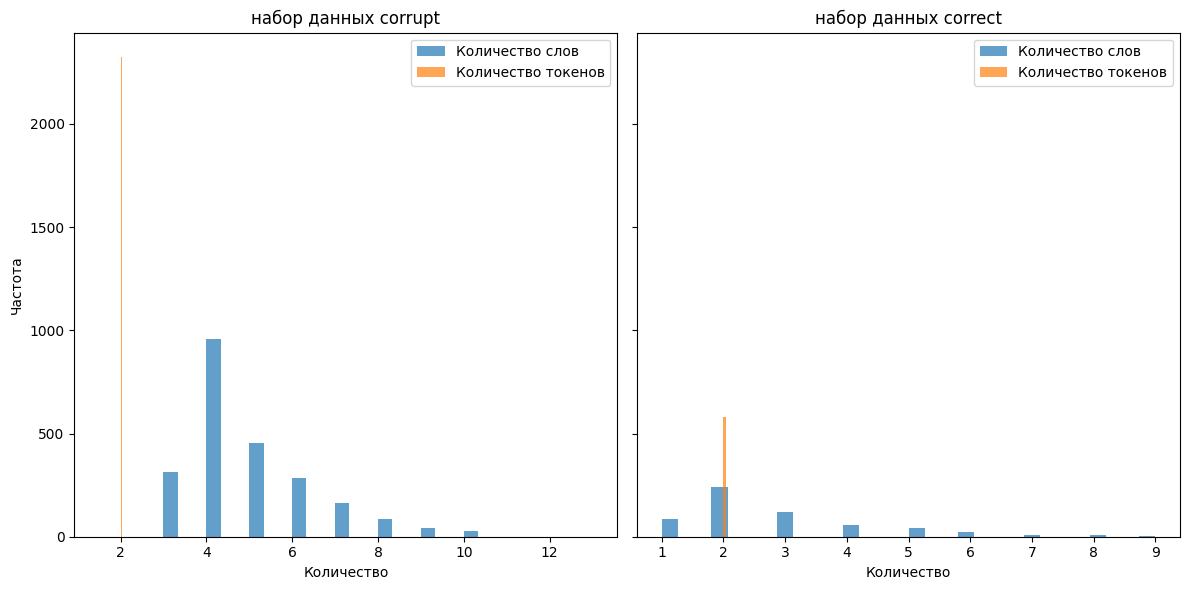

In [ ]:
import matplotlib.pyplot as plt

# Подсчет количества слов и токенов с использованием токенизатора
corrupt_word_counts = [len(example['corrupt'].split()) for example in dataset_to_tokenize['train']]
corrupt_token_counts = [len(tokenizer(example['corrupt'])) for example in dataset_to_tokenize['train']]

correct_word_counts = [len(example['correct'].split()) for example in dataset_to_tokenize['test']]
correct_token_counts = [len(tokenizer(example['correct'])) for example in dataset_to_tokenize['test']]

# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Гистограмма для тренировочного набора данных
axes[0].hist(corrupt_word_counts, bins=30, alpha=0.7, label='Количество слов')
axes[0].hist(corrupt_token_counts, bins=30, alpha=0.7, label='Количество токенов')
axes[0].set_title('набор данных corrupt')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Гистограмма для тестового набора данных
axes[1].hist(correct_word_counts, bins=30, alpha=0.7, label='Количество слов')
axes[1].hist(correct_token_counts, bins=30, alpha=0.7, label='Количество токенов')
axes[1].set_title('набор данных correct')
axes[1].set_xlabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# токенизируем датасет
MAX_LENGTH = 256

def tokenize_batch(batch):
    corrupt_encodings = tokenizer_01(
        batch['corrupt'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='longest',
        return_tensors=None
    )
    correct_encodings = tokenizer_01(
        batch['correct'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='longest',
        return_tensors=None
    )

    return {
        'input_ids': corrupt_encodings['input_ids'],
        'attention_mask': corrupt_encodings['attention_mask'],
        'labels': correct_encodings['input_ids'],
    }

dataset_tokenized_train = dataset_to_tokenize['train'].map(
    tokenize_batch,
    batched=True,
    remove_columns=['corrupt', 'correct']
)

dataset_tokenized_test = dataset_to_tokenize['test'].map(
    tokenize_batch,
    batched=True,
    remove_columns=['corrupt', 'correct']
)


Map:   0%|          | 0/2326 [00:00<?, ? examples/s]

Map:   0%|          | 0/582 [00:00<?, ? examples/s]

In [ ]:
# пример
dataset_tokenized_train[0]

{'input_ids': [11231,
  4658,
  29077,
  23,
  22,
  13570,
  1892,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'labels': [22, 13570, 3155, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [ ]:
# отправим датасет в память видеокарты, если такая есть
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_tokenized_train.set_format(type='torch', device=device)
dataset_tokenized_test.set_format(type='torch', device=device)

In [ ]:
dataset_tokenized_train

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2326
})

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer_01,
    padding=True,
    return_tensors="pt"
)

# создаем загрузчики данных
train_dataloader = DataLoader(dataset_tokenized_train, shuffle=True, batch_size=16, collate_fn=data_collator)
test_dataloader = DataLoader(dataset_tokenized_test, shuffle=False, batch_size=8, collate_fn=data_collator)

In [ ]:
from transformers import get_scheduler
from torch.optim import AdamW

# оптимизатор AdamW
optimizer = AdamW(model_01.parameters(), lr=5e-5)
# количество эпох
num_epochs = 7
# количество шагов
num_training_steps = num_epochs * len(train_dataloader)

# будем линейно увеличивать первые 200 шагов
lr_scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps= int(0.1 * num_epochs * len(train_dataloader)), # ~10% от общего числа шагов оптимально
    num_training_steps=num_training_steps
)

In [ ]:
!pip install evaluate

import evaluate
import numpy as np
import torch
from tqdm.auto import tqdm
from tqdm.notebook import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.6 MB/s eta 0:00:00


In [ ]:
# Задаем начальное значение лучшего WER
best_wer = 0.

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# цикл обучения
running_loss = []
for epoch in range(num_epochs):
    print(40*'-', f'\nEpoch {epoch+1}')

    # Переводим модель в режим обучения
    model_01.train()
    pbar = tqdm(train_dataloader, total=len(train_dataloader), desc='Training')

    # Итерируемся по данным для обучения
    for i, batch in enumerate(pbar):
        # Переводим данные на gpu
        batch = {k: v.to(device) for k, v in batch.items()}

        # Получаем прогнозы и потери от модели
        outputs = model_01(**batch)
        loss = outputs.loss

        # Выполняем обратное распространение и шаг оптимизатора
        loss.backward()
        optimizer.step()
        lr_scheduler.step()  # Обновляем планировщик скорости обучения
        optimizer.zero_grad()  # Очищаем градиенты

        running_loss.append(loss.item())
        pbar.set_postfix({'running_loss': np.mean(running_loss[-25:])})

    # Валидация модели
    print('\nValidating...')
    model_01.eval()  # Переводим модель в режим валидации

    # Инициализируем метрики
    wer_metric = evaluate.load("wer", trust_remote_code=True)
    val_loss = []

    pbar = tqdm(test_dataloader, total=len(test_dataloader), desc='Validation')
    # Итерируемся по валидационным данным
    for batch in tqdm(pbar):
        # Переводим данные на gpu
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():  # Выполняем без расчета градиентов
            outputs = model_01(**batch)

        # Генерация текста
        generated_tokens = model_01.generate(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_length=MAX_LENGTH
        )

        decoded_preds = tokenizer_01.batch_decode(generated_tokens, skip_special_tokens=True)
        decoded_labels = tokenizer_01.batch_decode(batch["labels"], skip_special_tokens=True)

        # Обновляем метрики
        wer_metric.add_batch(predictions=decoded_preds, references=decoded_labels)

        # Сохраняем потери
        val_loss.append(outputs.loss.item())
        pbar.set_postfix({'val_loss': np.mean(val_loss[-25:])})

    # Выводим итоги по метрикам
    print('Weighted Summary:')
    wer_score = wer_metric.compute()
    print(f"[{epoch+1}] Validation WER: {wer_score:.4f}")

    # Сохраняем модель при улучшении F1
    if wer_score < best_wer:
        best_wer = wer_score
        model_01.save_pretrained(f"best_model_oct_2025_wer={best_wer}")
        print(f"New best WER: {best_wer}. Model saved.")

---------------------------------------- 
Epoch 1


Training:   0%|          | 0/146 [00:00<?, ?it/s]


Validating...


Validation:   0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

...

Training:   0%|          | 0/146 [00:00<?, ?it/s]


Validating...


Validation:   0%|          | 0/73 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

Weighted Summary:
[7] Validation WER: 0.0276


In [ ]:
model_01.save_pretrained(f"best_model_oct_2025_wer={wer_score}")

In [ ]:
!zip -r the_best_model_wer.zip "/content/best_model_oct_2025_wer=0.027624309392265192"

  adding: content/best_model_oct_2025_wer=0.027624309392265192/ (stored 0%)
  adding: content/best_model_oct_2025_wer=0.027624309392265192/generation_config.json (deflated 29%)
  adding: content/best_model_oct_2025_wer=0.027624309392265192/config.json (deflated 63%)
  adding: content/best_model_oct_2025_wer=0.027624309392265192/model.safetensors (deflated 7%)


In [ ]:
from google.colab import files
files.download('the_best_model_wer.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Примените дообученную модель. Как раз здесь для оценки качества результата выведите на экран 10 текстов с предыдущего шага и их исправления с помощью модели.

In [ ]:
# выведем те же 10 результатов
encoded = tokenizer_01(
    transcriptions,
    padding="longest",
    max_length=MAX_INPUT,
    truncation=True,
    return_tensors="pt",
).to(device)

predicts = model_01.generate(encoded.input_ids) # Прогнозирование

decoded = tokenizer_01.batch_decode(predicts, skip_special_tokens=True) # Декодируем данные

for i in range(len(decoded)):
  print(f"{transcriptions[i]} => {decoded[i]}") # Было => Стало

 Аутам Джон. => аутам Джон
 Дайон Уорвик => дайон уорвик
 Дневник памяти. => дневник памяти
 Непть. => не пить
 Служебный реман => служебный роман
 унесенные ветром => унесенные ветром
 Эффект бабочки. => эффект бабочки
 Криминальная чтива. => криминальное чтиво
 Дай не трехо. => дай не трех
 Бабель Исаак, Эммануи Лавич. => бабель Исаак Исаак и Эммануэль Лавич


Было:

```
 Аутам Джон. => Аутам Джон
 Дайон Уорвик => Дайон Уорвик
 Дневник памяти. => Дневник памяти
 Непть. => Не пить.
 Служебный реман => Служебный роман
 унесенные ветром => Унесенные ветром
 Эффект бабочки. => Эффект бабочки.
 Криминальная чтива. => Криминальная чтива
 Дай не трехо. => Дай не трех.
 Бабель Исаак, Эммануи Лавич. => Бабель Исаак Исаак и Эммануил Лавич
```



**Вывод:** Как будто стало чуть лучше. Видно, что модель хотя бы научилась убирать точки и старается привести всё к lowercase. Служебный роман теперь не "реман".

## Шаг 5 (1 балл)

Время считать метрики и возвращаться к дообучению модели по необходимости. В этом шаге мы оцениваем только выполнение задания, а не значения метрик.

a) [Здесь](https://disk.yandex.ru/d/SPJU3lCt_cMDcw) лежат правильные ответы почти на все аудио - считайте метрики только для аудио, для которых мы дали вам ответы. Посчитайте [WER](https://docs.pytorch.org/torcheval/main/generated/torcheval.metrics.WordErrorRate.html) для модели whisper-small.

б) Посчитайте WER для whisper-small + исправление опечаток предобученной моделью (модель выберите самостоятельно!)

в) Посчитайте WER для whisper-small + дообученная Вами модель (данные для дообучения и модель выберите самостоятельно!)

In [ ]:
import json

with open("result_array.json", "r") as f:
    ground_truth_list = json.load(f)

# cделаем словарь url -> text
gt_dict = {item["url"]: item["text"] for item in ground_truth_list}

# те же 10 записей
with open("urls_normalized.tsv", "r") as f:
    urls = [line.strip() for line in f if line.strip()]

selected_indices = list(range(1, 20, 2)) # 10 штук
selected_urls = [urls[i] for i in selected_indices]

# оставляем только те, что есть в разметке
filtered_urls = []
filtered_transcriptions = []

for url, transcription in zip(selected_urls, transcriptions):
    if url in gt_dict:
        filtered_urls.append(url)
        filtered_transcriptions.append(transcription)
    else:
        print(f"Пропускаем аудио (нет разметки): {url}")

ground_truth = [gt_dict[url] for url in filtered_urls]

Пропускаем аудио (нет разметки): http://storage.mds.yandex.net:80/get-voicetoloka/1872575/3c0ebd62-2cc1-4c9c-be63-5733511a11cd


In [ ]:
import re

def normalize_text(text):
    # приводим к нижнему регистру, убираем знаки препинания (оставляем только буквы и пробелы)
    return re.sub(r'[^\w\s]', ' ', text.lower()).strip()

whisper_raw = [normalize_text(t) for t in filtered_transcriptions]
gt_norm = [normalize_text(t) for t in ground_truth]

In [ ]:
# б) Предобученная модель
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast
import torch

tokenizer_base = T5TokenizerFast.from_pretrained("UrukHan/t5-russian-spell")
model_base = AutoModelForSeq2SeqLM.from_pretrained("UrukHan/t5-russian-spell")
model_base.to("cuda" if torch.cuda.is_available() else "cpu")

encoded = tokenizer_base(
    filtered_transcriptions,
    padding="longest",
    max_length=256,
    truncation=True,
    return_tensors="pt",
).to(model_base.device)

with torch.no_grad():
    preds_base = model_base.generate(**encoded)

corrected_base = tokenizer_base.batch_decode(preds_base, skip_special_tokens=True)
corrected_base_norm = [normalize_text(t) for t in corrected_base]

In [ ]:
# в) Дообученная модель
# model_finetuned = AutoModelForSeq2SeqLM.from_pretrained("best_model_oct_2025_wer=0.027624309392265192")
# tokenizer_finetuned = T5TokenizerFast.from_pretrained("UrukHan/t5-russian-spell")

encoded = tokenizer_01(
    filtered_transcriptions,
    padding="longest",
    max_length=256,
    truncation=True,
    return_tensors="pt",
).to(model_01.device)

with torch.no_grad():
    preds_finetuned = model_01.generate(**encoded)

corrected_finetuned = tokenizer_01.batch_decode(preds_finetuned, skip_special_tokens=True)
corrected_finetuned_norm = [normalize_text(t) for t in corrected_finetuned]

In [ ]:
from jiwer import wer

wer_whisper = wer(gt_norm, whisper_raw)
wer_base = wer(gt_norm, corrected_base_norm)
wer_finetuned = wer(gt_norm, corrected_finetuned_norm)

print(f"WER (whisper only):        {wer_whisper:.4f}")
print(f"WER (whisper + base model): {wer_base:.4f}")
print(f"WER (whisper + finetuned):  {wer_finetuned:.4f}")

WER (whisper only):        0.5000
WER (whisper + base model): 0.6667
WER (whisper + finetuned):  0.5556


**Вывод:**
Файнтюн помог немного исправить базовую предобученную модель, но получилось так только потому, что она была довольно плохо обучена и, исправляя whisper, добавляла новые ошибки.

Собранный для дообучения датасет сравнительно плохого качества и я думаю, что если бы было время его почистить ещё, можно было бы ещё улучшить результат, так как качественные обучающие данные очень сильно влияют на результат.

whisper, так или иначе, довольно хорошо обученая модель (конечно, это же OpenAI) и улучшить её результат довольно сложно.

In [1]:
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.1 MB/s eta 0:00:00


In [2]:
# распаковка архива
!unzip -n result_audio.zip

Archive:  result_audio.zip
   creating: result_audio/
  inflating: result_audio/audio_26.wav  
  inflating: result_audio/audio_84.wav  
  inflating: result_audio/audio_81.wav  
  inflating: result_audio/audio_90.wav  
  inflating: result_audio/audio_24.wav  
  inflating: result_audio/audio_20.wav  
  inflating: result_audio/audio_8.wav  
  inflating: result_audio/audio_77.wav  
  inflating: result_audio/audio_68.wav  
  inflating: result_audio/audio_91.wav  
  inflating: result_audio/audio_51.wav  
  inflating: result_audio/audio_42.wav  
  inflating: result_audio/audio_56.wav  
  inflating: result_audio/audio_48.wav  
  inflating: result_audio/audio_33.wav  
  inflating: result_audio/audio_92.wav  
  inflating: result_audio/audio_9.wav  
  inflating: result_audio/audio_54.wav  
  inflating: result_audio/audio_0.wav  
  inflating: result_audio/audio_37.wav  
  inflating: result_audio/audio_4.wav  
  inflating: result_audio/audio_82.wav  
  inflating: result_audio/audio_89.wav  
  infla

In [3]:
# загрузка аудиозаписей из result_array.json
import os
import requests
from pathlib import Path
import json

with open('result_array.json', 'r', encoding='utf-8') as file:
    result_audio_list = json.load(file)

# загрузка аудио в папку
audio_dir = Path("result_audio")
audio_dir.mkdir(exist_ok=True)

res_audio_paths = []
for i, item in enumerate(result_audio_list):
    filename = audio_dir / f"audio_{i}.wav"
    if not filename.exists():
        url, text = item["url"], item["text"]
        print(f"Загрузка {i+1}/{len(result_audio_list)}: {url}")
        response = requests.get(url)
        with open(filename, "wb") as f:
            f.write(response.content)
    else:
        print(f"Файл {filename} уже существует")
    res_audio_paths.append(str(filename))

Файл result_audio/audio_0.wav уже существует
Файл result_audio/audio_1.wav уже существует
Файл result_audio/audio_2.wav уже существует
Файл result_audio/audio_3.wav уже существует
Файл result_audio/audio_4.wav уже существует
Файл result_audio/audio_5.wav уже существует
Файл result_audio/audio_6.wav уже существует
Файл result_audio/audio_7.wav уже существует
Файл result_audio/audio_8.wav уже существует
Файл result_audio/audio_9.wav уже существует
Файл result_audio/audio_10.wav уже существует
Файл result_audio/audio_11.wav уже существует
Файл result_audio/audio_12.wav уже существует
Файл result_audio/audio_13.wav уже существует
Файл result_audio/audio_14.wav уже существует
Файл result_audio/audio_15.wav уже существует
Файл result_audio/audio_16.wav уже существует
Файл result_audio/audio_17.wav уже существует
Файл result_audio/audio_18.wav уже существует
Файл result_audio/audio_19.wav уже существует
Файл result_audio/audio_20.wav уже существует
Файл result_audio/audio_21.wav уже существуе

In [4]:
ground_truth_arr = []

for item in result_audio_list:
    ground_truth_arr.append(item['text'])

ground_truth_arr

['жизнь других',
 'элтон джон',
 'побег из шоушенка',
 'мухаммед али',
 'дневник памяти',
 'рэйф файнс',
 'нефть',
 'золотая лихорадка',
 'служебный роман',
 'браден адамс',
 'унесенные ветром',
 'бренда ли',
 'эффект бабочки',
 'андрей сахаров',
 'криминальное чтиво',
 'зелная книга',
 'дэнни трехо',
 'билл найи',
 'бабель исаак эммануилович',
 'аристотель',
 'крашенинников степан петрович',
 'шон бин',
 'олеша юрий карлович',
 'однажды в америке',
 'огни большого города',
 'семь самураев',
 'синявский андрей донатович',
 'крестный отец два',
 'интерстеллар',
 'алладин',
 'головоломка',
 'ледниковый период',
 'отис реддинг',
 'бобби винтон',
 'коул портер',
 'адвокат дьявола',
 'отступники',
 'звздные войны эпизод пятый империя наносит ответный удар',
 'ирония судьбы или с лгким паром',
 'брат',
 'три идиота',
 'мой сосед тоторо',
 'бальмонт константин дмитриевич',
 'фил коллинз',
 'город бога',
 'джеки робинсон',
 'отель руанда',
 'кенни роджерс',
 'гладиатор',
 'джулианна мур',
 'эм

In [5]:
import re

def normalize_text(text):
    # приводим к нижнему регистру, убираем знаки препинания (оставляем только буквы и пробелы)
    return re.sub(r'[^\w\s]', ' ', text.lower()).strip()

In [6]:
# дёргаем whisper-small и распознаём текст для всего датасета
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch
import torchaudio
from jiwer import wer

# из документации https://huggingface.co/openai/whisper-small
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model.to("cuda" if torch.cuda.is_available() else "cpu")

# фиксим язык на русский + транскрибация
forced_decoder_ids = processor.get_decoder_prompt_ids(language="ru", task="transcribe")

whisper_small_transcriptions = []

for path in res_audio_paths:
    waveform, sampling_rate = torchaudio.load(path)

    # приводим к моно (если стерео), усредняя несколько каналов
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # пересэмплируем в 16 кГц
    if sampling_rate != 16000:
        waveform = torchaudio.functional.resample(waveform, sampling_rate, 16000)

    input_features = processor(
        waveform.squeeze().numpy(),
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features
    input_features = input_features.to(model.device)

    # генерим транскрибацию
    with torch.no_grad():
        predicted_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )

    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    whisper_small_transcriptions.append(transcription)
    print(f"{path}: {transcription}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

result_audio/audio_0.wav:  Жизнь других.
result_audio/audio_1.wav:  Аутам Джон.
result_audio/audio_2.wav:  Побег из Шаушенко
result_audio/audio_3.wav:  Мохаммед Али
result_audio/audio_4.wav:  Дневник памяти.
result_audio/audio_5.wav:  Ralf finds.
result_audio/audio_6.wav:  Непть.
result_audio/audio_7.wav:  Золотая лихорадка.
result_audio/audio_8.wav:  Служебный реман
result_audio/audio_9.wav:  Брайан Адамс
result_audio/audio_10.wav:  унесенные ветром
result_audio/audio_11.wav:  Брэнда Ли
result_audio/audio_12.wav:  Эффект бабочки.
result_audio/audio_13.wav:  Андрей Сахаров
result_audio/audio_14.wav:  Криминальная чтива.
result_audio/audio_15.wav:  Зеленая книга.
result_audio/audio_16.wav:  Дай не трехо.
result_audio/audio_17.wav:  Бил на и
result_audio/audio_18.wav:  Бабель Исаак, Эммануи Лавич.
result_audio/audio_19.wav:  Аристотель.
result_audio/audio_20.wav:  Крошенинников Степан Петрович
result_audio/audio_21.wav:  Шон Бин
result_audio/audio_22.wav:  Олеша Юрий Карлович
result_audi

In [7]:
whisper_small_transcriptions

[' Жизнь других.',
 ' Аутам Джон.',
 ' Побег из Шаушенко',
 ' Мохаммед Али',
 ' Дневник памяти.',
 ' Ralf finds.',
 ' Непть.',
 ' Золотая лихорадка.',
 ' Служебный реман',
 ' Брайан Адамс',
 ' унесенные ветром',
 ' Брэнда Ли',
 ' Эффект бабочки.',
 ' Андрей Сахаров',
 ' Криминальная чтива.',
 ' Зеленая книга.',
 ' Дай не трехо.',
 ' Бил на и',
 ' Бабель Исаак, Эммануи Лавич.',
 ' Аристотель.',
 ' Крошенинников Степан Петрович',
 ' Шон Бин',
 ' Олеша Юрий Карлович',
 ' Однажды в Америке',
 ' Огни большого города.',
 ' 7 самураев',
 ' Синявский Андрей Донатович',
 ' Крестный отец 2',
 ' Интерстеллер',
 ' Аладдина.',
 ' Голова ломка.',
 ' Ледниковый период',
 ' Otis Redding',
 ' Бобби Винтон',
 ' КОУ ПОРТЕР',
 ' адвокат делала',
 ' Отступники.',
 ' Звездной войны. Эпизод 5. Империя наносит ответный удар.',
 ' Ирония судьбы или с лёгким паром',
 ' Брат',
 ' 3. Идиота',
 ' Мой сосед татура.',
 ' Барьмонт, Костянкин Дмитрий.',
 ' Feel callings.',
 ' город бога',
 ' Джеки Робинсон',
 ' Отель 

In [ ]:
# считаем wer для whisper-small
whisper_small_transcriptions_norm = [normalize_text(t) for t in whisper_small_transcriptions]
wer_whisper_small = wer(ground_truth_arr, whisper_small_transcriptions_norm)
print(f"whisper-small WER: {wer_whisper_small:.4f}")

whisper-small WER: 0.3783


In [8]:
prefix = 'spell correct: '
whisper_small_transcriptions_with_prefix = [prefix + sequence for sequence in whisper_small_transcriptions]

In [9]:
whisper_small_transcriptions_with_prefix

['spell correct:  Жизнь других.',
 'spell correct:  Аутам Джон.',
 'spell correct:  Побег из Шаушенко',
 'spell correct:  Мохаммед Али',
 'spell correct:  Дневник памяти.',
 'spell correct:  Ralf finds.',
 'spell correct:  Непть.',
 'spell correct:  Золотая лихорадка.',
 'spell correct:  Служебный реман',
 'spell correct:  Брайан Адамс',
 'spell correct:  унесенные ветром',
 'spell correct:  Брэнда Ли',
 'spell correct:  Эффект бабочки.',
 'spell correct:  Андрей Сахаров',
 'spell correct:  Криминальная чтива.',
 'spell correct:  Зеленая книга.',
 'spell correct:  Дай не трехо.',
 'spell correct:  Бил на и',
 'spell correct:  Бабель Исаак, Эммануи Лавич.',
 'spell correct:  Аристотель.',
 'spell correct:  Крошенинников Степан Петрович',
 'spell correct:  Шон Бин',
 'spell correct:  Олеша Юрий Карлович',
 'spell correct:  Однажды в Америке',
 'spell correct:  Огни большого города.',
 'spell correct:  7 самураев',
 'spell correct:  Синявский Андрей Донатович',
 'spell correct:  Крестный 

In [ ]:
# б) Предобученная модель на полном датасете
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast
import torch

tokenizer_base = T5TokenizerFast.from_pretrained("UrukHan/t5-russian-spell")
model_base = AutoModelForSeq2SeqLM.from_pretrained("UrukHan/t5-russian-spell")
model_base.to("cuda" if torch.cuda.is_available() else "cpu")

encoded = tokenizer_base(
    whisper_small_transcriptions_with_prefix,
    padding="longest",
    max_length=256,
    truncation=True,
    return_tensors="pt",
).to(model_base.device)

with torch.no_grad():
    preds_base = model_base.generate(**encoded)

# считаем wer для предобученной UrukHan/t5-russian-spell
corrected_base = tokenizer_base.batch_decode(preds_base, skip_special_tokens=True)
corrected_base_norm = [normalize_text(t) for t in corrected_base]
wer_base = wer(ground_truth_arr, corrected_base_norm)
print(f"WER (whisper + base model): {wer_base:.4f}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

WER (whisper + base model): 0.3739


In [10]:
# (ОПЦИОНАЛЬНО) загрузка дообученной модели на инференс

!unzip the_best_model_wer.zip

Archive:  the_best_model_wer.zip
   creating: content/best_model_oct_2025_wer=0.027624309392265192/
  inflating: content/best_model_oct_2025_wer=0.027624309392265192/generation_config.json  
  inflating: content/best_model_oct_2025_wer=0.027624309392265192/config.json  
  inflating: content/best_model_oct_2025_wer=0.027624309392265192/model.safetensors  


In [11]:
# (ОПЦИОНАЛЬНО) загрузка дообученной модели на инференс
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast

MODEL_PATH = "./content/best_model_oct_2025_wer=0.027624309392265192"

# загружаем модель из сохранённой директории
model_01 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

# загружаем токенизатор из оригинальной модели
tokenizer_01 = T5TokenizerFast.from_pretrained("UrukHan/t5-russian-spell")

# переводим на GPU, если доступен
device = "cuda" if torch.cuda.is_available() else "cpu"
model_01.to(device)

The module name best_model_oct_2025_wer=0_dot_027624309392265192 (originally best_model_oct_2025_wer=0.027624309392265192) is not a valid Python identifier. Please rename the original module to avoid import issues.


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

In [12]:
# в) Дообученная модель на полном датасете
# model_finetuned = AutoModelForSeq2SeqLM.from_pretrained("best_model_oct_2025_wer=0.027624309392265192")
# tokenizer_finetuned = T5TokenizerFast.from_pretrained("UrukHan/t5-russian-spell")

encoded = tokenizer_01(
    whisper_small_transcriptions_with_prefix,
    padding="longest",
    max_length=256,
    truncation=True,
    return_tensors="pt",
).to(model_01.device)

with torch.no_grad():
    preds_finetuned = model_01.generate(**encoded)

corrected_finetuned = tokenizer_01.batch_decode(preds_finetuned, skip_special_tokens=True)
corrected_finetuned_norm = [normalize_text(t) for t in corrected_finetuned]
wer_finetuned = wer(ground_truth_arr, corrected_finetuned_norm)
print(f"WER (whisper + finetuned): {wer_finetuned:.4f}")

WER (whisper + finetuned): 0.3609


In [14]:
print(f"WER (whisper only):        {wer_whisper_small:.4f}")
print(f"WER (whisper + base model): {wer_base:.4f}")
print(f"WER (whisper + finetuned):  {wer_finetuned:.4f}")

WER (whisper only):        0.3783
WER (whisper + base model): 0.3739
WER (whisper + finetuned):  0.3609


**Вывод:** Метрика WER незначительно улучшилась после дообучения, процесс дообучения на специфических данных (kedrovdaniil/dataset_02) действительно позволил модели лучше адаптироваться к задаче исправления ошибок.
```
WER (whisper only):        0.3783
WER (whisper + base model): 0.3739
WER (whisper + finetuned):  0.3609
```

## Шаг 6 (3 балла)

В этом шаге предлагаем вам провести максимум рисерча и экспериментов для наиболее качественного решения задачи (в бесплатном google colab, без привлечения дополнительных мощностей)

* Поищите предобученные модели, применение которых для задачи speech-to-text дает меньше опечаток (меньше WER)

* Протестируйте несколько spell-correction моделей и сделайте выводы какая из них лучше (с точки зрения WER)

* Возьмите лучшую из найденных моделей и попытайтесь улучшить ее через шаг 4, как делали ранее. Попробуйте немного изменить обучение в шаге 4, чтобы добиться еще более хороших результатов (изменить данные/гиперпараметры и т.п.) и проведите соответствующий эксперимент. Объясните почему ваша модификация шага 4 теоретически может улучшить результаты и сделайте выводы о том, получилось ли улучшить качество (если нет, то предположите почему).

In [ ]:
# DELETE
# !pip install -q transformers evaluate jiwer datasets fsspec librosa soundfile pyctcdecode

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.6/533.6 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0,

In [ ]:
# распаковка архива
!unzip result_audio.zip

Archive:  result_audio.zip
   creating: result_audio/
  inflating: result_audio/audio_26.wav  
  inflating: result_audio/audio_84.wav  
  inflating: result_audio/audio_81.wav  
  inflating: result_audio/audio_90.wav  
  inflating: result_audio/audio_24.wav  
  inflating: result_audio/audio_20.wav  
  inflating: result_audio/audio_8.wav  
  inflating: result_audio/audio_77.wav  
  inflating: result_audio/audio_68.wav  
  inflating: result_audio/audio_91.wav  
  inflating: result_audio/audio_51.wav  
  inflating: result_audio/audio_42.wav  
  inflating: result_audio/audio_56.wav  
  inflating: result_audio/audio_48.wav  
  inflating: result_audio/audio_33.wav  
  inflating: result_audio/audio_92.wav  
  inflating: result_audio/audio_9.wav  
  inflating: result_audio/audio_54.wav  
  inflating: result_audio/audio_0.wav  
  inflating: result_audio/audio_37.wav  
  inflating: result_audio/audio_4.wav  
  inflating: result_audio/audio_82.wav  
  inflating: result_audio/audio_89.wav  
  infla

In [ ]:
# загрузка аудиозаписей из result_array.json
import os
import requests
from pathlib import Path
import json

with open('result_array.json', 'r', encoding='utf-8') as file:
    result_audio_list = json.load(file)

# загрузка аудио в папку
audio_dir = Path("result_audio")
audio_dir.mkdir(exist_ok=True)

res_audio_paths = []
for i, item in enumerate(result_audio_list):
    filename = audio_dir / f"audio_{i}.wav"
    if not filename.exists():
        url, text = item["url"], item["text"]
        print(f"Загрузка {i+1}/{len(result_audio_list)}: {url}")
        response = requests.get(url)
        with open(filename, "wb") as f:
            f.write(response.content)
    else:
        print(f"Файл {filename} уже существует")
    res_audio_paths.append(str(filename))

Файл result_audio/audio_0.wav уже существует
Файл result_audio/audio_1.wav уже существует
Файл result_audio/audio_2.wav уже существует
Файл result_audio/audio_3.wav уже существует
Файл result_audio/audio_4.wav уже существует
Файл result_audio/audio_5.wav уже существует
Файл result_audio/audio_6.wav уже существует
Файл result_audio/audio_7.wav уже существует
Файл result_audio/audio_8.wav уже существует
Файл result_audio/audio_9.wav уже существует
Файл result_audio/audio_10.wav уже существует
Файл result_audio/audio_11.wav уже существует
Файл result_audio/audio_12.wav уже существует
Файл result_audio/audio_13.wav уже существует
Файл result_audio/audio_14.wav уже существует
Файл result_audio/audio_15.wav уже существует
Файл result_audio/audio_16.wav уже существует
Файл result_audio/audio_17.wav уже существует
Файл result_audio/audio_18.wav уже существует
Файл result_audio/audio_19.wav уже существует
Файл result_audio/audio_20.wav уже существует
Файл result_audio/audio_21.wav уже существуе

In [ ]:
# (ОПЦИОНАЛЬНО) сохранение записей в архив
!zip -r result_audio.zip ./result_audio

  adding: result_audio/ (stored 0%)
  adding: result_audio/audio_26.wav (deflated 53%)
  adding: result_audio/audio_84.wav (deflated 31%)
  adding: result_audio/audio_81.wav (deflated 40%)
  adding: result_audio/audio_90.wav (deflated 36%)
  adding: result_audio/audio_24.wav (deflated 42%)
  adding: result_audio/audio_20.wav (deflated 27%)
  adding: result_audio/audio_8.wav (deflated 23%)
  adding: result_audio/audio_77.wav (deflated 37%)
  adding: result_audio/audio_68.wav (deflated 33%)
  adding: result_audio/audio_91.wav (deflated 21%)
  adding: result_audio/audio_51.wav (deflated 30%)
  adding: result_audio/audio_42.wav (deflated 29%)
  adding: result_audio/audio_56.wav (deflated 51%)
  adding: result_audio/audio_48.wav (deflated 21%)
  adding: result_audio/audio_33.wav (deflated 22%)
  adding: result_audio/audio_92.wav (deflated 30%)
  adding: result_audio/audio_9.wav (deflated 34%)
  adding: result_audio/audio_54.wav (deflated 31%)
  adding: result_audio/audio_0.wav (deflated 27%

In [ ]:
ground_truth_arr = []

for item in result_audio_list:
    ground_truth_arr.append(item['text'])

ground_truth_arr

['жизнь других',
 'элтон джон',
 'побег из шоушенка',
 'мухаммед али',
 'дневник памяти',
 'рэйф файнс',
 'нефть',
 'золотая лихорадка',
 'служебный роман',
 'браден адамс',
 'унесенные ветром',
 'бренда ли',
 'эффект бабочки',
 'андрей сахаров',
 'криминальное чтиво',
 'зелная книга',
 'дэнни трехо',
 'билл найи',
 'бабель исаак эммануилович',
 'аристотель',
 'крашенинников степан петрович',
 'шон бин',
 'олеша юрий карлович',
 'однажды в америке',
 'огни большого города',
 'семь самураев',
 'синявский андрей донатович',
 'крестный отец два',
 'интерстеллар',
 'алладин',
 'головоломка',
 'ледниковый период',
 'отис реддинг',
 'бобби винтон',
 'коул портер',
 'адвокат дьявола',
 'отступники',
 'звздные войны эпизод пятый империя наносит ответный удар',
 'ирония судьбы или с лгким паром',
 'брат',
 'три идиота',
 'мой сосед тоторо',
 'бальмонт константин дмитриевич',
 'фил коллинз',
 'город бога',
 'джеки робинсон',
 'отель руанда',
 'кенни роджерс',
 'гладиатор',
 'джулианна мур',
 'эм

In [ ]:
import re

def normalize_text(text):
    # приводим к нижнему регистру, убираем знаки препинания (оставляем только буквы и пробелы)
    return re.sub(r'[^\w\s]', ' ', text.lower()).strip()

In [ ]:
res_audio_paths

['result_audio/audio_0.wav',
 'result_audio/audio_1.wav',
 'result_audio/audio_2.wav',
 'result_audio/audio_3.wav',
 'result_audio/audio_4.wav',
 'result_audio/audio_5.wav',
 'result_audio/audio_6.wav',
 'result_audio/audio_7.wav',
 'result_audio/audio_8.wav',
 'result_audio/audio_9.wav',
 'result_audio/audio_10.wav',
 'result_audio/audio_11.wav',
 'result_audio/audio_12.wav',
 'result_audio/audio_13.wav',
 'result_audio/audio_14.wav',
 'result_audio/audio_15.wav',
 'result_audio/audio_16.wav',
 'result_audio/audio_17.wav',
 'result_audio/audio_18.wav',
 'result_audio/audio_19.wav',
 'result_audio/audio_20.wav',
 'result_audio/audio_21.wav',
 'result_audio/audio_22.wav',
 'result_audio/audio_23.wav',
 'result_audio/audio_24.wav',
 'result_audio/audio_25.wav',
 'result_audio/audio_26.wav',
 'result_audio/audio_27.wav',
 'result_audio/audio_28.wav',
 'result_audio/audio_29.wav',
 'result_audio/audio_30.wav',
 'result_audio/audio_31.wav',
 'result_audio/audio_32.wav',
 'result_audio/audio

In [ ]:
# ресемпл записей
import torch
import torchaudio
from pathlib import Path

input_dir = Path("result_audio")
output_dir = Path("result_audio_resampled")
output_dir.mkdir(exist_ok=True)

res_audio_resampled_paths = []
for wav_path in sorted(input_dir.glob("*.wav")):
    # загружаем аудио
    waveform, sr = torchaudio.load(wav_path)

    # преобразуем в моно (усреднение по каналам)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # пересэмплируем в 16 кГц, если нужно
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, orig_freq=sr, new_freq=16000)
        sr = 16000

    # сохраняем в новую папку с тем же именем
    output_path = output_dir / wav_path.name
    torchaudio.save(output_path, waveform, sr)
    res_audio_resampled_paths.append(str(output_path))
    print(f"Сохранён: {output_path}")

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Сохранён: result_audio_resampled/audio_0.wav
Сохранён: result_audio_resampled/audio_1.wav
Сохранён: result_audio_resampled/audio_10.wav
Сохранён: result_audio_resampled/audio_11.wav
Сохранён: result_audio_resampled/audio_12.wav
Сохранён: result_audio_resampled/audio_13.wav
Сохранён: result_audio_resampled/audio_14.wav
Сохранён: result_audio_resampled/audio_15.wav
Сохранён: result_audio_resampled/audio_16.wav
Сохранён: result_audio_resampled/audio_17.wav
Сохранён: result_audio_resampled/audio_18.wav
Сохранён: result_audio_resampled/audio_19.wav
Сохранён: result_audio_resampled/audio_2.wav
Сохранён: result_audio_resampled/audio_20.wav
Сохранён: result_audio_resampled/audio_21.wav
Сохранён: result_audio_resampled/audio_22.wav
Сохранён: result_audio_resampled/audio_23.wav
Сохранён: result_audio_resampled/audio_24.wav
Сохранён: result_audio_resampled/audio_25.wav
Сохранён: result_audio_resampled/audio_26.wav
Сохранён: result_audio_resampled/audio_27.wav
Сохранён: result_audio_resampled/audi

In [ ]:
res_audio_resampled_paths

['result_audio_resampled/audio_0.wav',
 'result_audio_resampled/audio_1.wav',
 'result_audio_resampled/audio_10.wav',
 'result_audio_resampled/audio_11.wav',
 'result_audio_resampled/audio_12.wav',
 'result_audio_resampled/audio_13.wav',
 'result_audio_resampled/audio_14.wav',
 'result_audio_resampled/audio_15.wav',
 'result_audio_resampled/audio_16.wav',
 'result_audio_resampled/audio_17.wav',
 'result_audio_resampled/audio_18.wav',
 'result_audio_resampled/audio_19.wav',
 'result_audio_resampled/audio_2.wav',
 'result_audio_resampled/audio_20.wav',
 'result_audio_resampled/audio_21.wav',
 'result_audio_resampled/audio_22.wav',
 'result_audio_resampled/audio_23.wav',
 'result_audio_resampled/audio_24.wav',
 'result_audio_resampled/audio_25.wav',
 'result_audio_resampled/audio_26.wav',
 'result_audio_resampled/audio_27.wav',
 'result_audio_resampled/audio_28.wav',
 'result_audio_resampled/audio_29.wav',
 'result_audio_resampled/audio_3.wav',
 'result_audio_resampled/audio_30.wav',
 're

In [ ]:
ground_truth_arr

['жизнь других',
 'элтон джон',
 'побег из шоушенка',
 'мухаммед али',
 'дневник памяти',
 'рэйф файнс',
 'нефть',
 'золотая лихорадка',
 'служебный роман',
 'браден адамс',
 'унесенные ветром',
 'бренда ли',
 'эффект бабочки',
 'андрей сахаров',
 'криминальное чтиво',
 'зелная книга',
 'дэнни трехо',
 'билл найи',
 'бабель исаак эммануилович',
 'аристотель',
 'крашенинников степан петрович',
 'шон бин',
 'олеша юрий карлович',
 'однажды в америке',
 'огни большого города',
 'семь самураев',
 'синявский андрей донатович',
 'крестный отец два',
 'интерстеллар',
 'алладин',
 'головоломка',
 'ледниковый период',
 'отис реддинг',
 'бобби винтон',
 'коул портер',
 'адвокат дьявола',
 'отступники',
 'звздные войны эпизод пятый империя наносит ответный удар',
 'ирония судьбы или с лгким паром',
 'брат',
 'три идиота',
 'мой сосед тоторо',
 'бальмонт константин дмитриевич',
 'фил коллинз',
 'город бога',
 'джеки робинсон',
 'отель руанда',
 'кенни роджерс',
 'гладиатор',
 'джулианна мур',
 'эм

1. Нашёл такие модели на Hugging face для задачи speech-to-text:


In [ ]:
# 1) jonatasgrosman/wav2vec2-large-xlsr-53-russian (Wav2Vec2 CTC)
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch
import torchaudio
from jiwer import wer

model_id = "jonatasgrosman/wav2vec2-large-xlsr-53-russian"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Wav2Vec2Processor.from_pretrained(model_id)
model = Wav2Vec2ForCTC.from_pretrained(model_id).to(device)
model.eval()

def transcribe_wav2vec2(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0, keepdim=True)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    input_values = processor(wav.squeeze().numpy(), sampling_rate=16000, return_tensors="pt").input_values.to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    pred_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(pred_ids)[0].lower()
    return transcription

# инференс
wav2vec2_large_xlsr_53_russian_preds = []
for path in res_audio_resampled_paths:
    try:
        transcription = transcribe_wav2vec2(path)
        wav2vec2_large_xlsr_53_russian_preds.append(transcription)
    except Exception as e:
        print("Error:", path, e)
        wav2vec2_large_xlsr_53_russian_preds.append("")

# считаем wer
wav2vec2_large_xlsr_53_russian_preds_norm = [normalize_text(t) for t in wav2vec2_large_xlsr_53_russian_preds]
wer_wav2vec2_large_xlsr_53_russian = wer(ground_truth_arr, wav2vec2_large_xlsr_53_russian_preds_norm)
print("jonatasgrosman/wav2vec2-large-xlsr-53-russian WER:", wer_wav2vec2_large_xlsr_53_russian)

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

jonatasgrosman/wav2vec2-large-xlsr-53-russian WER: 1.2130434782608697


In [ ]:
wav2vec2_large_xlsr_53_russian_preds_norm

['жизнь други',
 'а утрон джон',
 'унесенные ветром',
 'бренда ли',
 'эффект бабочки',
 'андрей сахаров',
 'криминальная чтива',
 'зеленая книга',
 'да и не трехо',
 'бил наи',
 'бабиль и саак эмануелович',
 'аристодиль',
 'побег из шаушенка',
 'крашенелников степан петрович',
 'сон бин',
 'олеша юрий калович',
 'однажды в америке',
 'огни большого города',
 'семь самураев',
 'синявский андрей донаторич',
 'крестный отец два',
 'интерстеллор',
 'олодин',
 'махамец али',
 'голова ломк',
 'ледниковый период',
 'отиц ратденг',
 'боби винтон',
 'коум портер',
 'адвокат девала',
 'отступники',
 'звездный войны эпизод пятый империя она носит ответный удар',
 'ирония судьбы или с легким паром',
 'брат',
 'днемни к памяти',
 'тре идиота',
 'мой сосвет тотора',
 'барьмонд костантин дмейтриии',
 'фил колинс',
 'город бога',
 'джейки робин сон',
 'отель роанда',
 'кенни роджерс',
 'угладиатор',
 'джуля намур',
 'аральф фаенс',
 'эма стоу',
 'гроздья гнева',
 'смоки робин сон',
 'окни большого гор

In [ ]:
# bond005/wav2vec2-large-ru-golos
from transformers import AutoProcessor, AutoModelForCTC
import torch, torchaudio
from jiwer import wer

model_id = "bond005/wav2vec2-large-ru-golos"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForCTC.from_pretrained(model_id).to(device)
model.eval()

def transcribe_golos(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0, keepdim=True)
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    input_values = processor(wav.squeeze().numpy(), sampling_rate=16000, return_tensors="pt").input_values.to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    pred_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(pred_ids)[0].lower()
    return transcription

wav2vec2_large_ru_golos_preds = []
for p in res_audio_resampled_paths:
    try:
        wav2vec2_large_ru_golos_preds.append(transcribe_golos(p))
    except Exception as e:
        print("err", p, e); wav2vec2_large_ru_golos_preds.append("")

wav2vec2_large_ru_golos_preds_norm = [normalize_text(t) for t in wav2vec2_large_ru_golos_preds]
print("bond005/wav2vec2-large-ru-golos WER:", wer(ground_truth_arr, wav2vec2_large_ru_golos_preds_norm))

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

bond005/wav2vec2-large-ru-golos WER: 1.117391304347826


In [ ]:
# mitchelldehaven/whisper-large-v2-ru
from transformers import pipeline
import torch
from jiwer import wer
import soundfile as sf

model_id = "mitchelldehaven/whisper-large-v2-ru"
device = "cuda" if torch.cuda.is_available() else "cpu"

asr = pipeline("automatic-speech-recognition", model=model_id, device=device, chunk_length_s=30)

whisper_large_ru_preds = []
for path in res_audio_resampled_paths:
    try:
        out = asr(path, return_timestamps=False)
        transcription = out["text"].lower()
        whisper_large_ru_preds.append(transcription)
    except Exception as e:
        print("err", path, e); whisper_large_ru_preds.append("")

whisper_large_ru_preds_norm = [normalize_text(t) for t in whisper_large_ru_preds]
print("whisper-large-v2-ru WER:", wer(ground_truth_arr, whisper_large_ru_preds_norm))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.17G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Device set to use cuda
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 90

whisper-large-v2-ru WER: 1.1478260869565218


Нашёл статью https://alphacephei.com/nsh/2025/04/18/russian-models.html где сравниваются актуальные модели для распознавания русской речи.

Лучший результат для датасета "Аудиокниги АЦ" у модели Vosk. Мне кажется это похожий домен с тем, чего мы пытаемся распознать. У модели есть документация и GitHub репозиторий, в котором есть пример для запуска модели на инференс из колаба:
https://github.com/alphacep/vosk-api/blob/master/python/example/colab/vosk.ipynb


In [ ]:
!pip3 install vosk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 25.9 MB/s eta 0:00:00
  Created wheel for srt: filename=srt-3.5.3-py3-none-any.whl size=22427 sha256=18d11b73da5b31625a146d4716b455dcd9caf3199c524ea10348415b8285c313
  Stored in directory: /root/.cache/pip/wheels/7e/75/5b/e1d5c3756631e4bda806f6cc9640153b39484bb6f7b0b8def3
Successfully built srt


In [ ]:
# Model page: https://alphacephei.com/vosk/
from vosk import Model, KaldiRecognizer
import wave
import json
from jiwer import wer

vosk_model = Model(lang="ru") # автоматически скачает модель

# инференс
vosk_preds = []
for path in res_audio_resampled_paths:
    try:
        # открываем аудиофайл
        wf = wave.open("/content/" + path, "rb")
        # проверка формата (обязательно: mono, 16-bit, 16kHz)
        if wf.getnchannels() != 1 or wf.getsampwidth() != 2 or wf.getframerate() != 16000:
            raise ValueError("Аудио должно быть mono, 16-bit, 16kHz")

        rec = KaldiRecognizer(vosk_model, wf.getframerate())
        rec.SetWords(True)

        # обработка чанками
        while True:
            data = wf.readframes(4000)
            if len(data) == 0:
                break
            rec.AcceptWaveform(data)

        wf.close()

        # получаем финальнфй текст
        result = json.loads(rec.FinalResult())
        transcription = result.get("text", "").strip()
        vosk_preds.append(transcription)

    except Exception as e:
        print(f"Ошибка Vosk - path: {path}: {e}")
        vosk_preds.append("")

# нормализация и расчёт WER
vosk_preds_norm = [normalize_text(t) for t in vosk_preds]
wer_vosk = wer(ground_truth_arr, vosk_preds_norm)
print(f"Vosk (ru) WER: {wer_vosk:.3f}")

Vosk (ru) WER: 1.130


In [ ]:
vosk_preds_norm

['жизнь других',
 'а элтон джон',
 'унесённые ветром',
 'бренда ли',
 'эффект бабочки',
 'андрей сахаров',
 'криминальное чтиво',
 'зелёная книга',
 'дэнни трехо',
 'билл найи ей',
 'бабель исаак эммануила вич',
 'аристотель',
 'побег из шоушенка',
 'крашенинников степан петрович',
 'шон бин',
 'олеша юрий карлович',
 'однажды в америке',
 'огни большого города',
 'семь самураев',
 'синявский андрей доната эйч',
 'крестный отец два',
 'интерстеллар',
 'алладин',
 'мохаммед али',
 'головоломка',
 'ледниковый период',
 'отис реддинг',
 'бобби винтон',
 'коул портер',
 'адвокат дьявола',
 'отступники',
 'звёздные войны эпизод пятый империя наносит ответный удар',
 'ирония судьбы или с лёгким паром',
 'брат',
 'дневник памяти',
 'клей идиота',
 'мой сосед тоторо',
 'бальмонт константин дмитриевич',
 'фил коллинз',
 'город бога',
 'джеки робинсон',
 'отель роланда',
 'кенни роджерс',
 'гладиатор',
 'джулианна мур',
 'ральф файнс',
 'эмма стоун',
 'гроздья гнева',
 'смоки робинсон',
 'огни б

**Сравнение WER**
- Vosk (ru) = 1.130
- jonatasgrosman/wav2vec2-large-xlsr-53-russian (Wav2Vec2 CTC) = 1.213
- bond005/wav2vec2-large-ru-golos = 1.117
- mitchelldehaven/whisper-large-v2-ru = 1.148

bond005/wav2vec2-large-ru-golos показывает наилучший WER. Модель легковесная и показывает хороший результат в распознавании русской речи.

## Spell-correction
Для spell-correction задачи нашёл 2 модели:
*- RuM2M100: https://huggingface.co/ai-forever/RuM2M100-418M*
- FredT5-large-spell: https://huggingface.co/ai-forever/FRED-T5-large-spell  
в статье https://habr.com/ru/companies/sberdevices/articles/763932/

In [ ]:
from transformers import T5ForConditionalGeneration, AutoTokenizer

path_to_model = "ai-forever/FRED-T5-large-spell"

FRED_T5_large_spell_model = T5ForConditionalGeneration.from_pretrained(path_to_model)
FRED_T5_large_spell_tokenizer = AutoTokenizer.from_pretrained(path_to_model, eos_token="</s>")
prefix = "Исправь: "

FRED_T5_large_spell_transcriptions_corrected = []

for i, sentence in enumerate(whisper_small_transcriptions):
    try:
        # токенизация
        sentence = prefix + sentence
        encodings = FRED_T5_large_spell_tokenizer(sentence, return_tensors="pt")
        # генерация исправленного текста
        generated_tokens = FRED_T5_large_spell_model.generate(
                **encodings, eos_token_id=FRED_T5_large_spell_tokenizer.eos_token_id, early_stopping=True)

        # декодирование
        answer = FRED_T5_large_spell_tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
        print(f"Corrected: {answer}")
        FRED_T5_large_spell_transcriptions_corrected.append(answer)
        print(f"[{i+1}/{len(whisper_small_transcriptions)}] Исправлено: '{sentence}' => '{answer}'")
    except Exception as e:
        print(f"Ошибка при исправлении '{sentence}': {e}")
        FRED_T5_large_spell_transcriptions_corrected.append(sentence)

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.28G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Corrected: ['Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других']
[1/96] Исправлено: 'Исправь:  Жизнь других.' => '['Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других']'
Corrected: ['- А потом Джон. - А потом Джон. - А потом Джон. - А потом Джон.']
[2/96] Исправлено: 'Исправь:  Аутам Джон.' => '['- А потом Джон. - А потом Джон. - А потом Джон. - А потом Джон.']'
Corrected: ['- Побег из Шаушенка - 2Побег из Шаушенка - 1П']
[3/96] Исправлено: 'Исправь:  Побег из Шаушенко' => '['- Побег из Шаушенка - 2Побег из Шаушенка - 1П']'
Corrected: ['1-й Мохаммед Али, Мохаммед Али I-й Али I-й Али I-']
[4/96] Исправлено: 'Исправь:  Мохаммед Али' => '['1-й Мохаммед Али, Мохаммед Али I-й Али I-й Али I-']'
Corrected: ['— Дневник памяти. — Дневник памяти. — Дневник памяти. — Дневник памяти.']
[5/96] Исправлено: 'Исправь:  Дневник памяти.' => '['— Дневник памяти. — Дневник памяти. — Дневник памяти. — Дневник памят

In [ ]:
FRED_T5_large_spell_transcriptions_corrected

[['Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других. Жизнь других'],
 ['- А потом Джон. - А потом Джон. - А потом Джон. - А потом Джон.'],
 ['- Побег из Шаушенка - 2Побег из Шаушенка - 1П'],
 ['1-й Мохаммед Али, Мохаммед Али I-й Али I-й Али I-'],
 ['— Дневник памяти. — Дневник памяти. — Дневник памяти. — Дневник памяти.'],
 ['— Ralf Raiders. — Ralf Raiders. — Ralf Raiders'],
 ['Не пить. Не есть. Не курить. Не пить. Не есть. Не пить. Не пить'],
 ['Золотая лихорадка. Золотая лихорадка. 1. Золотая лихорадка. 2. Золотая'],
 ['1 Служебный роман2 Служебный роман3 Роман4 Сюжетный роман5 Роман6 Роман'],
 ['- Брайан Адамс - Брайан Адамс - Брайан Адамс - Брайан Адамс - Брайан Адамс'],
 ['Унесенные ветром1 - унесенные ветром2 - унесенные ветром3D - унесенные ветром'],
 ['У Брэнда Ли: Брэнда Ли1:1 Брэнда Ли2:1'],
 ['— Эффект бабочки. — Эффект бабочки. — Эффект бабочки. — Э'],
 [' - Андрей Сахаров  Андрей Сахаров  Андрей Сахаров  Андрей Сахаров  Андрей Сахаров'],
 

In [ ]:
type(FRED_T5_large_spell_transcriptions_corrected)

list

In [ ]:
# нормализация и расчёт WER
FRED_T5_large_spell_transcriptions_corrected_norm = [normalize_text(t[0]) for t in FRED_T5_large_spell_transcriptions_corrected]
wer_FRED_T5_large_spell = wer(ground_truth_arr, FRED_T5_large_spell_transcriptions_corrected_norm)
print(f"FRED_T5_large_spell WER: {wer_FRED_T5_large_spell:.3f}")

FRED_T5_large_spell WER: 3.278


Есть подозрение, что модель не умеет работать с короткими фразами и обучалась исправлять только предложения. Видно, что модель пытается продолжить фразу до размера предложения или до максиамально возможной длины, повторяя одно и тоже. В другом ноутбуке я попробовал запустить модель с примером как из документации и там было всё неплохо. Возможно, дообучив модель на собранном синтетическом датасете, получится подкорректировать это поведение.

Нашлась ещё одна модель - https://github.com/ai-forever/sage

In [ ]:
!git clone https://github.com/ai-forever/sage.git

Cloning into 'sage'...
remote: Enumerating objects: 733, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 733 (delta 64), reused 57 (delta 51), pack-reused 590 (from 1)
Receiving objects: 100% (733/733), 15.43 MiB | 16.17 MiB/s, done.
Resolving deltas: 100% (416/416), done.


In [ ]:
cd sage

/content/sage


In [ ]:
!pip install .
!pip install -e .[errant]

Processing /content/sage
  Preparing metadata (setup.py) ... done
Processing ./wheels/augmentex-1.0.3-py3-none-any.whl (from sage==1.1.0)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of sage to determine which version is compatible with other requirements. This could take a while.
ERROR: Package 'sage' requires a different Python: 3.12.12 not in '<3.11.0,>=3.8.0'
Obtaining file:///content/sage
  Preparing metadata (setup.py) ... done
Processing ./wheels/augmentex-1.0.3-py3-none-any.whl (from sage==1.1.0)
  Using cached timeout-decorator-0.5.0.tar.gz (4.8 kB)
  Preparing metadata (setup.py) ... done
  Using cached matplotlib-3.6.3.tar.gz (35.9 MB)
  Preparing metadata (setup.py) ... done
  Using cached torch-2.2.0-cp312-cp312-manylinux1_x86_64.whl.metadata (25 kB)
INFO: pip is looking at multiple versions of sage to determine whic

In [ ]:
import os
import torch
from sage.spelling_correction import T5ModelForSpellingCorruption, RuM2M100ModelForSpellingCorrection, AvailableCorrectors

ModuleNotFoundError: No module named 'errant'

In [ ]:
sage_m2m100_corrector = RuM2M100ModelForSpellingCorrection.from_pretrained(AvailableCorrectors.sage_m2m100_1B.value)

NameError: name 'RuM2M100ModelForSpellingCorrection' is not defined

In [ ]:
result_1b = sage_m2m100_corrector.correct(whisper_small_transcriptions[0])
print("sage_m2m100")
print(result_1b[0])
print()

Но из-за требования более старого python модель не завелась в колабе. Из-за конфликта версий также не завелась "ai-forever/RuM2M100-418M" (вернее сначала завелась, а потом перестало работать, восстановить работоспособность не удалось).

In [ ]:
# DELETE
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# загружаем модель и токенизатор
path_to_model = "ai-forever/RuM2M100-418M"
spell_model_RuM2M100_418M = M2M100ForConditionalGeneration.from_pretrained(
    path_to_model,
    device_map=None,
    torch_dtype=torch.float16
).to(device)
spell_tokenizer_RuM2M100_418M = M2M100Tokenizer.from_pretrained(path_to_model, src_lang="ru", tgt_lang="ru")

RuM2M100_418M_transcriptions_corrected = []

for i, transcription in enumerate(whisper_small_transcriptions):
    try:
        # токенизация с указанием устройства
        inputs = spell_tokenizer_RuM2M100_418M(
            transcription,
            return_tensors="pt",
            truncation=True,
            max_length=256
        ).to(device)

        # генерация исправленного текста
        with torch.no_grad():
            generated_tokens = spell_model_RuM2M100_418M.generate(
                **inputs,
                forced_bos_token_id=spell_tokenizer_RuM2M100_418M.get_lang_id("ru")
            )

        # декодирование
        corrected = spell_tokenizer_RuM2M100_418M.batch_decode(generated_tokens, skip_special_tokens=True)[0]
        RuM2M100_418M_transcriptions_corrected.append(corrected)
        print(f"[{i+1}/{len(whisper_small_transcriptions)}] Исправлено: '{transcription}' => '{corrected}'")

    except Exception as e:
        print(f"Ошибка при исправлении '{transcription}': {e}")
        RuM2M100_418M_transcriptions_corrected.append(transcription)

NotImplementedError: Cannot copy out of meta tensor; no data! Please use torch.nn.Module.to_empty() instead of torch.nn.Module.to() when moving module from meta to a different device.

In [ ]:
# DELETE
# считаем WER
RuM2M100_418M_transcriptions_corrected_norm = [normalize_text(t) for t in RuM2M100_418M_transcriptions_corrected]
wer_RuM2M100_418M = wer(ground_truth_arr, RuM2M100_418M_transcriptions_corrected_norm)
print(f"RuM2M100_418M WER: {wer_RuM2M100_418M:.3f}")

RuM2M100_418M WER: 0.378


Что если замерить оригинальную 'ai-forever/ruT5-base', а не предобученную 'UrukHan/t5-russian-spell' модель?

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from transformers import AutoModelForSeq2SeqLM, T5TokenizerFast

MODEL_NAME = 'ai-forever/ruT5-base'
MAX_INPUT = 256

# загрузка модели и токенизатора
rut5_base_tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)
rut5_base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

In [ ]:
# токенизирование данных
task_prefix = "Spell correct: "
encoded = rut5_base_tokenizer(
  [task_prefix + sequence for sequence in whisper_small_transcriptions],
  padding="longest",
  max_length=MAX_INPUT,
  truncation=True,
  return_tensors="pt",
)

In [ ]:
# прогнозирование
predicts = rut5_base_model.generate(**encoded.to(device))

In [ ]:
# декодируем данные
rut5_base_decoded = rut5_base_tokenizer.batch_decode(predicts, skip_special_tokens=True)

In [ ]:
rut5_base_decoded

['..................',
 '  ',
 '                  ',
 '- - - - - - - - - - - - - - - - - - -',
 'ДневникДневникДневникДневник.Дневник.Дневник.Дневник',
 'find:::: find',
 ',,,,,',
 '',
 '                  ',
 ':                ',
 '..................',
 'Бр',
 ',,',
 'в',
 ',     ',
 '',
 ',,,,,',
 ' на           ',
 '........)))))))))))',
 '- Ар',
 '                  ',
 ',,,,,',
 'Оле Оле',
 'в в',
 '',
 'в в',
 ': : : : : :  : ',
 '',
 '',
 '',
 ',,,,,,,',
 ',,,,,,,,,,,,,,,,,,,',
 '::::::',
 'Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби Бобби',
 '. . . . . . .-',
 'в',
 '',
 '..  ',
 '        ',
 '',
 '',
 ',,,',
 '......)))))',
 'во во',
 'Spec Spec Spec Spec Spec Spec Spec Spec Specs',
 '..................',
 'Руанда Рунд',
 '           W W W W W W W W',
 ',',
 '- - - - - - - - - - - - - - - - - - -',
 'ммммммммммммммммммм',
 '-  :  : ) : ) ) )',
 'иииииииииииииииииии',
 '',
 '',
 '',
 'но но но но но но но но но но но

Локальный вывод: Модель галлюционирует при прозьбе подкорректировать фразу и не понимает, что от неё хотят. Видимо, модель обучалась на больших текстах и просто не умеет работать с короткими фразами, да ещё и исправлять их. WER, соответственно, будет очень высокий.

In [ ]:
# считаем WER
rut5_base_decoded_norm = [normalize_text(t) for t in rut5_base_decoded]
wer_rut5_base = wer(ground_truth_arr, rut5_base_decoded_norm)
print(f"rut5_base WER: {wer_rut5_base:.3f}")

rut5_base WER: 1.300


## Дообучение
Изначально хотел дообучить FredT5-large-spell, однако несколько раз словил "Out of memory", модель достаточно большая и не влезает на GPU вместе с датасетом.

Поэтому остановился на небольшой модели: дообучим 'ai-forever/ruT5-base' на датасете. Интересно, улучшится ли результат, если взять оригинальную предобученную модель и дообучить на собранном датасете.

In [ ]:
# DELETE
# !pip install -U accelerate transformers datasets evaluate torch

In [ ]:
import numpy as np
import evaluate
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
    BitsAndBytesConfig
)
import torch

set_seed(42)

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
dataset_02 = load_dataset("kedrovdaniil/dataset_02")

In [ ]:
dataset = dataset_02['train'].train_test_split(test_size=0.2)
dataset["train"][0]

{'corrupt': 'напомни про встречуу', 'correct': 'напомни про встречу'}

In [ ]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

path_to_model = 'ai-forever/ruT5-base'

ru_t5_base_model = T5ForConditionalGeneration.from_pretrained(path_to_model)
ru_t5_base_tokenizer = AutoTokenizer.from_pretrained(path_to_model, eos_token="</s>")

In [ ]:
PREFIX = "Spell correct: " # используем префикс

def preprocess_function(examples):
    # добавляем префикс к тексту с ошибками (corrupt)
    inputs = [PREFIX + ex for ex in examples['corrupt']]
    targets = examples['correct']

    # токенизируем инпуты
    model_inputs = ru_t5_base_tokenizer(inputs, max_length=256, truncation=True, padding=True)

    # токенизируем цели (correct)
    labels = ru_t5_base_tokenizer(targets, max_length=256, truncation=True, padding=True)

    # присваиваем токенизированные цели как 'labels' для модели
    model_inputs["labels"] = labels["input_ids"]

    # заменяем pad_token_id на -100, чтобы loss игнорировал эти токены
    model_inputs["labels"] = [
        [(l if l != ru_t5_base_tokenizer.pad_token_id else -100) for l in label] for label in model_inputs["labels"]
    ]

    return model_inputs

In [ ]:
# токенизация датасета
tokenized_datasets = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)
tokenized_datasets["train"][0]

{'input_ids': [11231,
  4658,
  29077,
  23,
  9,
  6406,
  82,
  7438,
  18,
  2,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'labels': [9,
  6406,
  82,
  7438,
  2,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100,
  -100]}

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer=ru_t5_base_tokenizer, model=ru_t5_base_model)

In [ ]:
wer_metric = evaluate.load("wer", trust_remote_code=True)

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # заменяем -100 на pad_token_id, чтобы токенизатор не интерпретировал -100 как токен
    labels = np.where(labels != -100, labels, ru_t5_base_tokenizer.pad_token_id)

    # декодируем токены в текст
    decoded_preds = ru_t5_base_tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = ru_t5_base_tokenizer.batch_decode(labels, skip_special_tokens=True)

    # счиатем WER
    wer = wer_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"wer": wer}

In [ ]:
# настройка обучения
training_args = Seq2SeqTrainingArguments(
    output_dir="./results_finetuned_ruT5_base", # для результатов
    overwrite_output_dir=True, # перезаписывать директорию при новом запуске
    num_train_epochs=4,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=3e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="no", # убрал, потому что после 1 эпохи падал колаб (vram)
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=False,
    metric_for_best_model="wer", # оптимизируем по WER
    greater_is_better=False, # меньший WER лучше
    report_to="none", # отключаем логирование в wandb/mlflow
    fp16=True, # для больших моделей на GPU, если поддерживается
    gradient_checkpointing=True,
    save_total_limit=1,
    dataloader_num_workers=0,
    seed=42
)

In [ ]:
# обучение
trainer = Seq2SeqTrainer(
    model=ru_t5_base_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=ru_t5_base_tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

trainer.save_model("./models/my_finetuned_ru_t5_base_tokenizer")
# токенизатор можно не сохранять и пользоваться базовым, т.к. словарь не менялся
ru_t5_base_tokenizer.save_pretrained("./models/my_finetuned_ru_t5_base_tokenizer")
print("Модель дообучена и сохранена в ./models/my_finetuned_ru_t5_base_tokenizer")

/tmp/ipython-input-1991933164.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
100,6.512900
200,1.067700
300,0.459000
400,0.387300
500,0.290000
600,0.233700
700,0.203400
800,0.206500


Модель дообучена и сохранена в ./models/my_finetuned_ru_t5_base_tokenizer


In [ ]:
# (ОПЦИОНАЛЬНО) сохранение модели
import shutil
from google.colab import files

# пути
model_dir = "./models/my_finetuned_ru_t5_base_tokenizer"
zip_path = "./my_finetuned_ru_t5_base.zip"

# архивируем
shutil.make_archive(base_name="./my_finetuned_ru_t5_base", format="zip", root_dir=model_dir)
print(f"Модель запакована в: {zip_path}")

# загрузка
files.download(zip_path)

Модель запакована в: ./my_finetuned_ru_t5_base.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# (ОПЦИОНАЛЬНО) распаковка модели
import os
os.makedirs("./models", exist_ok=True)

!unzip my_finetuned_ru_t5_base.zip -d ./models/my_finetuned_ru_t5_base_tokenizer

Archive:  my_finetuned_ru_t5_base.zip
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/config.json  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/model.safetensors  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/spiece.model  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/tokenizer.json  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/generation_config.json  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/tokenizer_config.json  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/training_args.bin  
  inflating: ./models/my_finetuned_ru_t5_base_tokenizer/special_tokens_map.json  


Теперь посчитаем WER на наших аудиозаписях

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

MODEL_PATH = "./models/my_finetuned_ru_t5_base_tokenizer"

loaded_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
loaded_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

# переводим модель в режим оценки
loaded_model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
whisper_small_transcriptions

[' Жизнь других.',
 ' Аутам Джон.',
 ' Побег из Шаушенко',
 ' Мохаммед Али',
 ' Дневник памяти.',
 ' Ralf finds.',
 ' Непть.',
 ' Золотая лихорадка.',
 ' Служебный реман',
 ' Брайан Адамс',
 ' унесенные ветром',
 ' Брэнда Ли',
 ' Эффект бабочки.',
 ' Андрей Сахаров',
 ' Криминальная чтива.',
 ' Зеленая книга.',
 ' Дай не трехо.',
 ' Бил на и',
 ' Бабель Исаак, Эммануи Лавич.',
 ' Аристотель.',
 ' Крошенинников Степан Петрович',
 ' Шон Бин',
 ' Олеша Юрий Карлович',
 ' Однажды в Америке',
 ' Огни большого города.',
 ' 7 самураев',
 ' Синявский Андрей Донатович',
 ' Крестный отец 2',
 ' Интерстеллер',
 ' Аладдина.',
 ' Голова ломка.',
 ' Ледниковый период',
 ' Otis Redding',
 ' Бобби Винтон',
 ' КОУ ПОРТЕР',
 ' адвокат делала',
 ' Отступники.',
 ' Звездной войны. Эпизод 5. Империя наносит ответный удар.',
 ' Ирония судьбы или с лёгким паром',
 ' Брат',
 ' 3. Идиота',
 ' Мой сосед татура.',
 ' Барьмонт, Костянкин Дмитрий.',
 ' Feel callings.',
 ' город бога',
 ' Джеки Робинсон',
 ' Отель 

In [ ]:
corrected_texts = []

# обрабатываем по одному
for i in range(len(whisper_small_transcriptions)):
    text = whisper_small_transcriptions[i]
    input_with_prefix = "Spell correct: " + text

    # токенизируем один пример
    inputs = loaded_tokenizer(
        input_with_prefix,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    ).to(device)

    # генерация
    with torch.no_grad():
        outputs = loaded_model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=256,
            num_beams=3,
            early_stopping=True,
        )

    # декодируем
    corrected = loaded_tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    corrected_texts.append(corrected)
    print(f"'{text}' => '{corrected}'")

    # очистка
    del inputs, outputs
    torch.cuda.empty_cache()

# считаем WER
corrected_texts_norm = [normalize_text(t) for t in corrected_texts]
wer_my_finetuned_ru_t5_base = wer(ground_truth_arr, corrected_texts_norm)
print(f"my_finetuned_ru_t5_base WER: {wer_my_finetuned_ru_t5_base:.3f}")

' Жизнь других.' => 'Жизнь других'
' Аутам Джон.' => 'Аутам Джон'
' Побег из Шаушенко' => 'Побег из Шаушенко'
' Мохаммед Али' => 'Мохаммед Али'
' Дневник памяти.' => 'Дневник памяти'
' Ralf finds.' => 'Ralf finds'
' Непть.' => 'Непть'
' Золотая лихорадка.' => 'Золотая лихорадка'
' Служебный реман' => 'Служебный реман'
' Брайан Адамс' => 'Брайан Адамс'
' унесенные ветром' => 'унесенные ветром'
' Брэнда Ли' => 'Брэнда Ли'
' Эффект бабочки.' => 'Эффект бабочки'
' Андрей Сахаров' => 'Андрей Сахаров'
' Криминальная чтива.' => 'Криминальное чтиво'
' Зеленая книга.' => 'Зеленая книга'
' Дай не трехо.' => 'Дай не три'
' Бил на и' => 'Бил на и'
' Бабель Исаак, Эммануи Лавич.' => 'Бабель Исаак, Эммануи Лавич'
' Аристотель.' => 'Аристотель'
' Крошенинников Степан Петрович' => 'Крошенинников Степан Петрович'
' Шон Бин' => 'Шон Бин'
' Олеша Юрий Карлович' => 'Олеша Юрий Карлович'
' Однажды в Америке' => 'Однажды в Америке'
' Огни большого города.' => 'Огни большого города'
' 7 самураев' => '7 самур

**Выводы:**  
`Название фильма: "Джейсон ворн и его ультиматум"` 😃

Можно сказать, что модель удалось дообучить.

Изначальный результат:  
rut5_base WER: 1.300  
После дообучения:  
my_finetuned_ru_t5_base WER: 0.378  

Метрика WER у дообученной модели равна 0.378 и соответствует метрике WER у whisper-small (0.3783). Это означает, что после дообучения результат не улучшился и не ухудшился.

Мысли по дообучению:
1. Наверное, в идеале было бы не генерировать синтетический датасет, а просто спарсить сайты о фильмах в интернете, структурировать и почистить данные, а для дообучения под задачу spell-checker потом с помощью ручных алгоритмов добавить фонетические и лексические ошибки в правильные примеры, можно добавить ошибки сегментации распознанной фразы по словам. Можно ещё попробовать использовать добавление ошибок в текст при помощи модели ai-forever/sage (https://github.com/ai-forever/sage/blob/main/notebooks/text_corruption_demo.ipynb).
2. Чем качественнее обучающий датасет, тем лучше модель будет работать. Нет смысла дообучать модель на мусорном датасете. Чем больше качественных примеров увидит модель, тем лучше она научится исправлять ошибки.
3. Моделей, поддерживающих русский язык, довольно мало, а те, что есть, не всегда запускаются в колабе, для них нужно своё окружение и свои версии пакетов.
4. Возможно, если нагенерировать датасет побольше и дообучить на нём модель, то получится ещё немного уменьшить WER.

P.S. Если что-то при запуске падает, возможно не хватает каких-то пакетов, которые нужно догрузить через !pip install. Очень много времени потратил на борьбу с разными версиями пакетов при развёртывании разных моделей на инференс, вроде всё проверил, но некоторые ячейки могли потеряться.